# Amazon Reviews Dataset Analysis

## Step 1: Load and Explore the Data

This notebook loads the Amazon Electronics reviews dataset from a compressed JSON Lines format (.json.gz). 
JSON Lines is a format where each line in the file is a separate, complete JSON object. We'll use Python's 
built-in `gzip` and `json` libraries to read this format efficiently.

In [1]:
import pandas as pd
import gzip
import json

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the JSON Lines Data

The data file is in JSON Lines format (`.json.gz`), which is a compressed text file where:
- Each line contains one complete JSON object
- Multiple JSON objects are separated by newlines
- The entire file is gzipped for compression

We'll:
1. Open the gzip file using `gzip.open()`
2. Read each line and parse it as JSON
3. Collect all parsed objects into a list
4. Convert the list to a pandas DataFrame

In [2]:
# File path
file_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/Electronics_5.json.gz"

# Read the gzip file and parse JSON Lines
data = []
with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

# Convert to pandas DataFrame
df = pd.DataFrame(data)

print(f"Successfully loaded {len(data)} records from the compressed file!")
print(f"DataFrame created with shape: {df.shape}")

Successfully loaded 6739590 records from the compressed file!
DataFrame created with shape: (6739590, 12)


## Step 3: Preview and Inspect Dataset Structure

Now let's examine the dataset by:
- Viewing the first 5 rows with `df.head()`
- Checking the dataset dimensions (rows × columns) with `df.shape`
- Listing all column names with `df.columns`
- Getting data types and memory info with `df.info()`
- Computing descriptive statistics with `df.describe()`

In [3]:
# Display first 5 rows
print("=" * 80)
print("FIRST 5 ROWS OF THE DATASET:")
print("=" * 80)
print(df.head())

# Print dataset shape and column names
print("\n" + "=" * 80)
print("DATASET SHAPE AND COLUMNS:")
print("=" * 80)
print(f"Shape (rows, columns): {df.shape}")
print(f"\nColumn Names:\n{list(df.columns)}")

# Display dataset info
print("\n" + "=" * 80)
print("DATASET INFO:")
print("=" * 80)
print(df.info())

# Display descriptive statistics
print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS:")
print("=" * 80)
print(df.describe())

FIRST 5 ROWS OF THE DATASET:
   overall vote  verified   reviewTime      reviewerID        asin  \
0      5.0   67      True  09 18, 1999   AAP7PPBU72QFM  0151004714   
1      3.0    5      True  10 23, 2013  A2E168DTVGE6SV  0151004714   
2      5.0    4     False   09 2, 2008  A1ER5AYS3FQ9O3  0151004714   
3      5.0   13     False   09 4, 2000  A1T17LMQABMBN5  0151004714   
4      3.0    8      True   02 4, 2000  A3QHJ0FXK33OBE  0151004714   

                            style      reviewerName  \
0       {'Format:': ' Hardcover'}      D. C. Carrad   
1  {'Format:': ' Kindle Edition'}               Evy   
2       {'Format:': ' Paperback'}             Kcorn   
3       {'Format:': ' Hardcover'}   Caf Girl Writes   
4       {'Format:': ' Hardcover'}  W. Shane Schmidt   

                                          reviewText  \
0  This is the best novel I have read in 2 or 3 y...   
1  Pages and pages of introspection, in the style...   
2  This is the kind of novel to read when you hav..

## Step 4: Check for Missing Values

Missing or null values can significantly impact data analysis. We'll:
- Count null values in each column using `df.isnull().sum()`
- Calculate the percentage of missing data for each column
- Visualize which columns have missing data
- Identify which rows have any missing values

In [4]:
# Count null values per column
print("=" * 80)
print("NULL VALUES COUNT PER COLUMN:")
print("=" * 80)
null_counts = df.isnull().sum()
print(null_counts)

# Calculate percentage of missing data
print("\n" + "=" * 80)
print("PERCENTAGE OF MISSING DATA PER COLUMN:")
print("=" * 80)
null_percentage = (df.isnull().sum() / len(df)) * 100
print(null_percentage)

# Total null values in dataset
print("\n" + "=" * 80)
print("TOTAL NULL VALUES IN DATASET:")
print("=" * 80)
total_nulls = df.isnull().sum().sum()
print(f"Total null values: {total_nulls}")
print(f"Percentage of total data that is null: {(total_nulls / (df.shape[0] * df.shape[1])) * 100:.2f}%")

# Check rows with any missing values
print("\n" + "=" * 80)
print("ROWS WITH ANY MISSING VALUES:")
print("=" * 80)
rows_with_nulls = df.isnull().any(axis=1).sum()
print(f"Number of rows with at least one null value: {rows_with_nulls}")
print(f"Number of rows with no missing values: {len(df) - rows_with_nulls}")

NULL VALUES COUNT PER COLUMN:
overall                 0
vote              5790916
verified                0
reviewTime              0
reviewerID              0
asin                    0
style             3192170
reviewerName          925
reviewText           1353
summary               812
unixReviewTime          0
image             6619632
dtype: int64

PERCENTAGE OF MISSING DATA PER COLUMN:
overall            0.000000
vote              85.923862
verified           0.000000
reviewTime         0.000000
reviewerID         0.000000
asin               0.000000
style             47.364454
reviewerName       0.013725
reviewText         0.020075
summary            0.012048
unixReviewTime     0.000000
image             98.220099
dtype: float64

TOTAL NULL VALUES IN DATASET:
Total null values: 15605808
Percentage of total data that is null: 19.30%

ROWS WITH ANY MISSING VALUES:
Number of rows with at least one null value: 6700840
Number of rows with no missing values: 38750


## Step 5: Save the DataFrame as CSV

Since loading the large compressed JSON file takes significant time, we'll save the DataFrame as a CSV file. 
This allows us to:
- Quickly reload the data in future sessions without decompressing the .json.gz file
- Share the processed data in a more universal format
- Avoid repeatedly parsing the entire JSON Lines file

Note: The CSV file will be stored in the `processed/` subdirectory of the data folder.

In [ ]:
import os

# Create the processed directory if it doesn't exist
processed_dir = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed"
os.makedirs(processed_dir, exist_ok=True)

# Define the CSV output path
csv_path = os.path.join(processed_dir, "electronics_reviews.csv")

# Save the DataFrame to CSV (without the index column)
df.to_csv(csv_path, index=False)

print(f"✓ DataFrame successfully saved to:")
print(f"  {csv_path}")
print(f"\nFile size: {os.path.getsize(csv_path) / (1024**2):.2f} MB")

## Step 6: Reload Data from CSV (Fast Loading)

In future sessions, you can skip the JSON Lines parsing step entirely and reload the data directly from the CSV file 
using `pd.read_csv()`. This is much faster than parsing the compressed JSON file. Simply run the cell below to reload 
the data:

**Option 1:** Load all data into memory (default)
- Use `df = pd.read_csv(csv_path)` for normal analysis

**Option 2:** Load data in chunks (for very large files)
- Use `chunksize` parameter if the file is too large to fit in memory

For this dataset, Option 1 should work fine. Here's how to do it:

In [ ]:
# Path to the CSV file
csv_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_reviews.csv"

# Reload the DataFrame from CSV (this is much faster than loading from JSON)
df_reloaded = pd.read_csv(csv_path)

print("✓ DataFrame successfully reloaded from CSV!")
print(f"\nDataFrame shape: {df_reloaded.shape}")
print(f"Columns: {list(df_reloaded.columns)}")
print(f"\nFirst 3 rows:")
print(df_reloaded.head(3))

# Verify it's the same data
print(f"\n✓ Data integrity check:")
print(f"  Original df shape: {df.shape}")
print(f"  Reloaded df shape: {df_reloaded.shape}")
print(f"  Shapes match: {df.shape == df_reloaded.shape}")

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_67053/2885784326.py:5: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reloaded = pd.read_csv(csv_path)


✓ DataFrame successfully reloaded from CSV!

DataFrame shape: (6739590, 12)
Columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image']

First 3 rows:
   overall vote  verified   reviewTime      reviewerID        asin  \
0      5.0   67      True  09 18, 1999   AAP7PPBU72QFM  0151004714   
1      3.0    5      True  10 23, 2013  A2E168DTVGE6SV  0151004714   
2      5.0    4     False   09 2, 2008  A1ER5AYS3FQ9O3  0151004714   

                            style  reviewerName  \
0       {'Format:': ' Hardcover'}  D. C. Carrad   
1  {'Format:': ' Kindle Edition'}           Evy   
2       {'Format:': ' Paperback'}         Kcorn   

                                          reviewText  \
0  This is the best novel I have read in 2 or 3 y...   
1  Pages and pages of introspection, in the style...   
2  This is the kind of novel to read when you hav...   

                                            

## Step 7: Load and Explore the Electronics Metadata Dataset

The metadata file contains product-level information for the Electronics category, including fields such as title, brand, and product description.
We will load the compressed JSON Lines file, convert it into a pandas DataFrame, inspect its structure, and then save it to CSV for faster reuse.


In [ ]:
meta_file_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/meta_Electronics.jsonl.gz"

meta_data = []
with gzip.open(meta_file_path, "rt", encoding="utf-8") as f:
    for line in f:
        meta_data.append(json.loads(line))

df_meta = pd.DataFrame(meta_data)
print(f"Successfully loaded {len(df_meta)} records from the metadata file!")
print(f"Metadata DataFrame shape: {df_meta.shape}")


### Metadata Dataset Preview and Inspection

Inspect the loaded metadata DataFrame by viewing the first rows, checking the shape and column names, and reviewing data types.


In [ ]:
print("=" * 80)
print("FIRST 5 ROWS OF THE METADATA DATASET:")
print("=" * 80)
print(df_meta.head())

print(" " + "=" * 80)
print("METADATA DATAFRAME SHAPE AND COLUMNS:")
print("=" * 80)
print(f"Shape (rows, columns): {df_meta.shape}")
print(f" Column Names: {list(df_meta.columns)}")

print(" " + "=" * 80)
print("METADATA DATAFRAME INFO:")
print("=" * 80)
print(df_meta.info())

print(" " + "=" * 80)
print("DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS:")
print("=" * 80)
print(df_meta.describe())


### Save Metadata as CSV

Saving the metadata DataFrame to CSV allows fast reloading in later sessions without parsing the compressed JSON file again.


In [ ]:
processed_dir = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed"
os.makedirs(processed_dir, exist_ok=True)
meta_csv_path = os.path.join(processed_dir, "meta_electronics.csv")
df_meta.to_csv(meta_csv_path, index=False)
print(f"✓ Metadata DataFrame successfully saved to:")
print(f"  {meta_csv_path}")
print(f" File size: {os.path.getsize(meta_csv_path) / (1024**2):.2f} MB")


### Reload Metadata from CSV

In future sessions, reload the metadata directly from `meta_electronics.csv` for much faster startup.


In [13]:
meta_csv_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/meta_electronics.csv"
df_meta_reloaded = pd.read_csv(meta_csv_path)
print(" ✓ Metadata DataFrame successfully reloaded from CSV!")
print(f" Reloaded DataFrame shape: {df_meta_reloaded.shape}")
print(f"Columns: {list(df_meta_reloaded.columns)}")
print(f" First 3 rows:")
print(df_meta_reloaded.head(3))

print(f" ✓ Data integrity check:")
print(f"  Original df_meta shape: {df_meta.shape}")
print(f"  Reloaded df_meta_reloaded shape: {df_meta_reloaded.shape}")
print(f"  Shapes match: {df_meta.shape == df_meta_reloaded.shape}")


 ✓ Metadata DataFrame successfully reloaded from CSV!
 Reloaded DataFrame shape: (275174, 16)
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
 First 3 rows:
     main_category                                              title  \
0  All Electronics             FS-1051 FATSHARK TELEPORTER V3 HEADSET   
1  All Electronics                      Ce-H22B12-S1 4Kx2K Hdmi 4Port   
2        Computers  Digi-Tatoo Decal Skin Compatible With MacBook ...   

   average_rating  rating_number  \
0             3.5              6   
1             5.0              1   
2             4.5            246   

                                            features  \
0                                                 []   
1         ['UPC: 662774021904', 'Weight: 0.600 lbs']   
2  ['WARNING: Please IDENTIFY MODEL NUMBER on the...   

           

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_97244/1029933988.py:2: DtypeWarning: Columns (0: price) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta_reloaded = pd.read_csv(meta_csv_path)


## Step 8: Quick Start — Load Processed Datasets

Skip the full processing pipeline and load both datasets directly from the saved CSV files.
This is the recommended entry point for all analysis sessions after the initial data preparation is complete.

In [2]:
import pandas as pd
import numpy as np
import os
import gzip, json

# Load reviews dataset
reviews_csv = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_reviews.csv"
df = pd.read_csv(reviews_csv, low_memory=False)
print(f"Reviews loaded   : {df.shape[0]:,} rows  x  {df.shape[1]} columns")

# Load metadata — re-parse from source if the CSV is incomplete
meta_csv = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/meta_electronics.csv"
EXPECTED_META_ROWS = 1_610_012   # full metadata count from original JSONL

df_meta = pd.read_csv(meta_csv, low_memory=False)
print(f"Metadata from CSV: {df_meta.shape[0]:,} rows  x  {df_meta.shape[1]} columns")

if df_meta.shape[0] < EXPECTED_META_ROWS * 0.95:
    print(f"\n⚠  CSV is incomplete ({df_meta.shape[0]:,} vs expected ~{EXPECTED_META_ROWS:,} rows).")
    print("   Re-parsing from original JSONL source — this will take a few minutes…")
    meta_gz = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/meta_Electronics.jsonl.gz"
    meta_data = []
    with gzip.open(meta_gz, "rt", encoding="utf-8") as f:
        for line in f:
            meta_data.append(json.loads(line))
    df_meta = pd.DataFrame(meta_data)
    print(f"   Parsed {len(df_meta):,} records. Re-saving complete CSV…")
    df_meta.to_csv(meta_csv, index=False)
    print(f"   ✓ Saved to {meta_csv}")
else:
    print("   ✓ CSV is complete — no re-parse needed.")

print(f"\nReviews columns  : {list(df.columns)}")
print(f"Metadata columns : {list(df_meta.columns)}")

Reviews loaded   : 6,739,590 rows  x  12 columns
Metadata from CSV: 1,610,012 rows  x  16 columns
   ✓ CSV is complete — no re-parse needed.

Reviews columns  : ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image']
Metadata columns : ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


## Step 9: EDA — Reviews Dataset

Quick exploratory analysis covering rating distribution, verified purchase breakdown, review volume over time, and missing value profile.

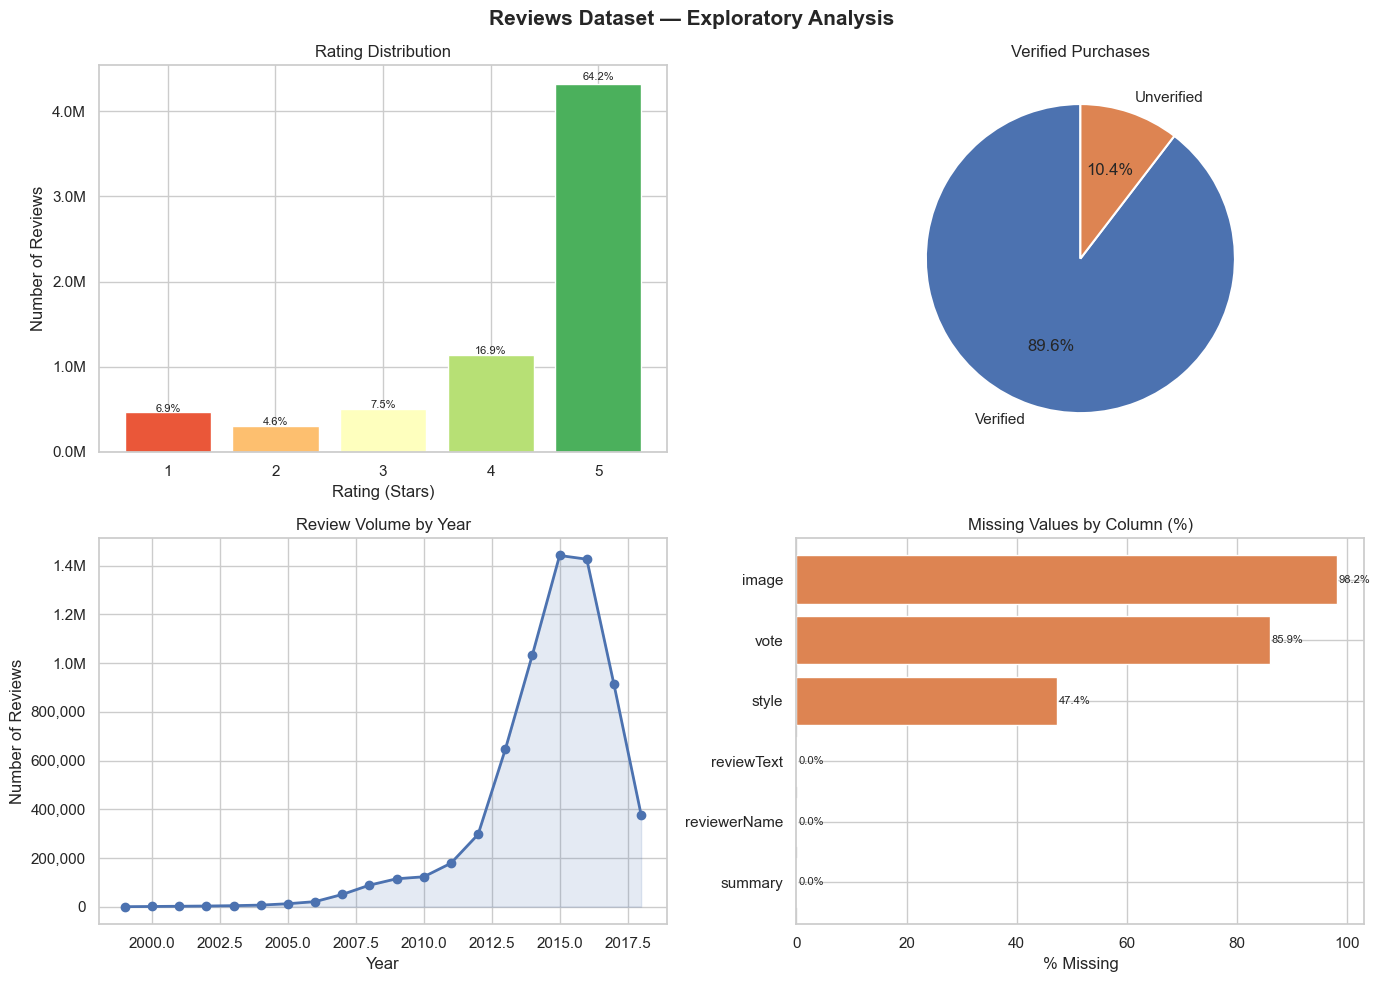

=== Reviews Dataset Summary ===
Total reviews      : 6,739,590
Unique products    : 160,052
Unique reviewers   : 728,719
Date range         : 1999 – 2018
Average rating     : 4.27 ± 1.20
Verified purchase %: 89.6%
Reviews with text  : 6,737,950  (100.0%)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Reviews Dataset — Exploratory Analysis", fontsize=15, fontweight="bold")

# 1. Rating distribution
rating_counts = df["overall"].value_counts().sort_index()
colors = sns.color_palette("RdYlGn", 5)
bars = axes[0, 0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[0, 0].set_title("Rating Distribution")
axes[0, 0].set_xlabel("Rating (Stars)")
axes[0, 0].set_ylabel("Number of Reviews")
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, val in zip(bars, rating_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                    f"{val/len(df)*100:.1f}%", ha="center", fontsize=8)

# 2. Verified vs Unverified purchase
v_counts = df["verified"].value_counts()
axes[0, 1].pie(v_counts, labels=["Verified", "Unverified"] if v_counts.index[0] else ["Unverified", "Verified"],
               autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"], startangle=90,
               wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0, 1].set_title("Verified Purchases")

# 3. Review volume over time
df_temp = df.copy()
df_temp["year"] = pd.to_datetime(df_temp["unixReviewTime"], unit="s").dt.year
year_counts = df_temp["year"].value_counts().sort_index()
axes[1, 0].plot(year_counts.index, year_counts.values, marker="o", linewidth=2, color="#4C72B0")
axes[1, 0].fill_between(year_counts.index, year_counts.values, alpha=0.15, color="#4C72B0")
axes[1, 0].set_title("Review Volume by Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Number of Reviews")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x):,}"))

# 4. Missing value summary (columns with any missing data)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
axes[1, 1].barh(missing.index, missing.values / len(df) * 100, color="#DD8452")
axes[1, 1].set_title("Missing Values by Column (%)")
axes[1, 1].set_xlabel("% Missing")
for i, v in enumerate(missing.values):
    axes[1, 1].text(v / len(df) * 100 + 0.3, i, f"{v/len(df)*100:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("=== Reviews Dataset Summary ===")
df_temp["year"] = pd.to_datetime(df_temp["unixReviewTime"], unit="s").dt.year
print(f"Total reviews      : {len(df):,}")
print(f"Unique products    : {df['asin'].nunique():,}")
print(f"Unique reviewers   : {df['reviewerID'].nunique():,}")
print(f"Date range         : {df_temp['year'].min()} – {df_temp['year'].max()}")
print(f"Average rating     : {df['overall'].mean():.2f} ± {df['overall'].std():.2f}")
print(f"Verified purchase %: {df['verified'].mean()*100:.1f}%")
print(f"Reviews with text  : {df['reviewText'].notna().sum():,}  ({df['reviewText'].notna().mean()*100:.1f}%)")

## Step 10: EDA — Metadata Dataset

Explore the product catalogue: check available fields, missing values, price distribution, and top brands.

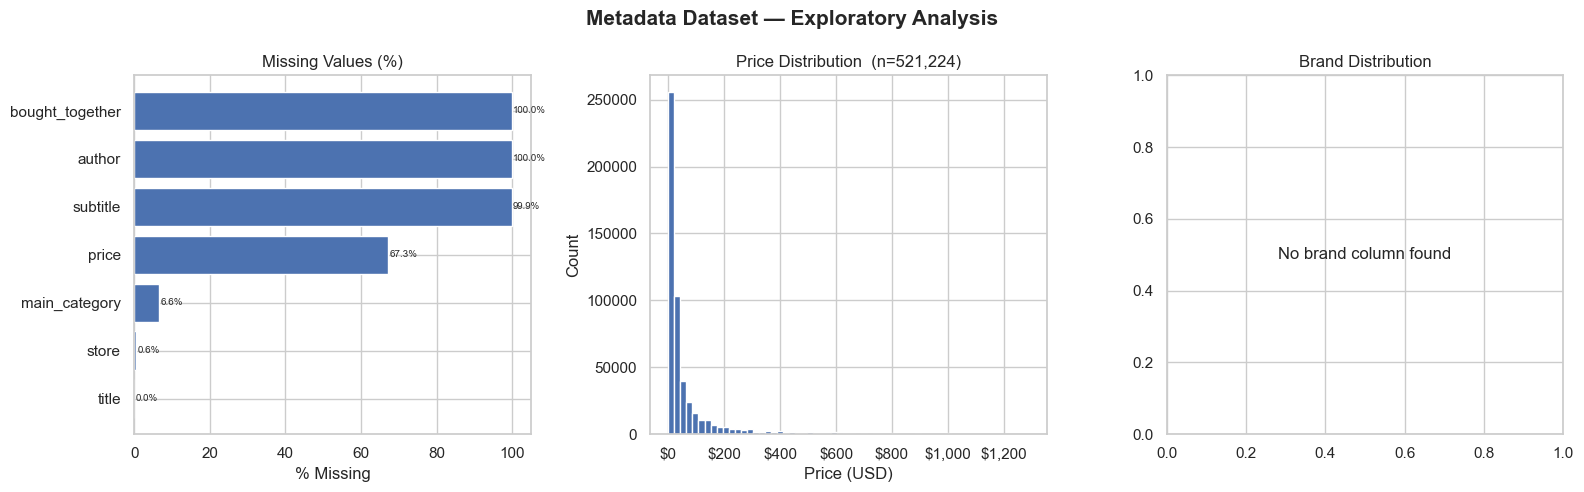

=== Metadata Dataset Summary ===
Total products : 1,610,012
Columns        : ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Metadata Dataset — Exploratory Analysis", fontsize=15, fontweight="bold")

# 1. Missing values
meta_missing = df_meta.isnull().sum()
meta_missing = meta_missing[meta_missing > 0].sort_values(ascending=True)
if not meta_missing.empty:
    axes[0].barh(meta_missing.index, meta_missing.values / len(df_meta) * 100, color="#4C72B0")
    axes[0].set_title("Missing Values (%)")
    axes[0].set_xlabel("% Missing")
    for i, v in enumerate(meta_missing.values):
        axes[0].text(v / len(df_meta) * 100 + 0.3, i, f"{v/len(df_meta)*100:.1f}%", va="center", fontsize=7)
else:
    axes[0].text(0.5, 0.5, "No missing values", ha="center", va="center")
    axes[0].set_title("Missing Values")

# 2. Price distribution
if "price" in df_meta.columns:
    prices = pd.to_numeric(
        df_meta["price"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce"
    ).dropna()
    prices = prices[(prices > 0) & (prices < prices.quantile(0.99))]
    axes[1].hist(prices, bins=60, color="#4C72B0", edgecolor="white")
    axes[1].set_title(f"Price Distribution  (n={len(prices):,})")
    axes[1].set_xlabel("Price (USD)")
    axes[1].set_ylabel("Count")
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
else:
    axes[1].text(0.5, 0.5, "No price column", ha="center", va="center")
    axes[1].set_title("Price Distribution")

# 3. Top brands by product count
brand_col_meta = next((c for c in df_meta.columns if c.lower() in ("brand", "brand_name")), None)
if brand_col_meta:
    top_brands = df_meta[brand_col_meta].value_counts().dropna().head(15)
    axes[2].barh(top_brands.index[::-1], top_brands.values[::-1], color="#55A868")
    axes[2].set_title("Top 15 Brands by Product Count")
    axes[2].set_xlabel("Number of Products")
    axes[2].tick_params(axis="y", labelsize=7)
else:
    axes[2].text(0.5, 0.5, "No brand column found", ha="center", va="center")
    axes[2].set_title("Brand Distribution")

plt.tight_layout()
plt.show()

print("=== Metadata Dataset Summary ===")
print(f"Total products : {len(df_meta):,}")
print(f"Columns        : {list(df_meta.columns)}")
if brand_col_meta:
    print(f"Unique brands  : {df_meta[brand_col_meta].nunique():,}")
    asin_overlap = df_meta["asin"].isin(df["asin"]).sum()
    print(f"ASINs also in reviews: {asin_overlap:,}  ({asin_overlap/len(df_meta)*100:.1f}% of products)")

## Step 11: Merge Reviews with Product Metadata

Join the reviews and metadata DataFrames on `asin` (product ID) using a **left join** to preserve all reviews.
This attaches the product title, brand, and category to every review row.

In [5]:
# ── Diagnostics: find the right join key ─────────────────────────────────────
print("=== Join Key Diagnostics ===\n")
print(f"Review ASIN sample  : {df['asin'].head(5).tolist()}")

asin_candidates = [c for c in df_meta.columns if "asin" in c.lower()]
print(f"Metadata ASIN cols  : {asin_candidates}")
for col in asin_candidates:
    sample = df_meta[col].dropna().head(5).tolist()
    raw_overlap = df_meta[col].isin(df["asin"]).sum()
    clean_overlap = df_meta[col].astype(str).str.strip().isin(df["asin"].str.strip()).sum()
    print(f"\n  '{col}'")
    print(f"    sample          : {sample}")
    print(f"    overlap (raw)   : {raw_overlap:,}  ({raw_overlap/len(df_meta)*100:.1f}% of meta products)")
    print(f"    overlap (strip) : {clean_overlap:,}  ({clean_overlap/len(df_meta)*100:.1f}% of meta products)")

# ── Pick the best join column ─────────────────────────────────────────────────
best_col = max(
    asin_candidates,
    key=lambda c: df_meta[c].astype(str).str.strip().isin(df["asin"].str.strip()).sum()
)
print(f"\nBest join key: '{best_col}'")

# ── Build slim metadata and merge ─────────────────────────────────────────────
meta_keep = [best_col]
for candidate in ["title", "store", "price", "main_category", "categories", "average_rating"]:
    if candidate in df_meta.columns:
        meta_keep.append(candidate)

df_meta_slim = (
    df_meta[meta_keep]
    .copy()
    .assign(**{best_col: df_meta[best_col].astype(str).str.strip()})
    .rename(columns={best_col: "asin", "store": "brand", "main_category": "category"})
    .drop_duplicates(subset="asin")
)

df_clean = df.copy()
df_clean["asin"] = df_clean["asin"].str.strip()

df_merged = df_clean.merge(df_meta_slim, on="asin", how="left")

# ── Report ─────────────────────────────────────────────────────────────────────
matched   = df_merged["title"].notna().sum() if "title" in df_merged.columns else \
            df_merged["asin"].isin(df_meta_slim["asin"]).sum()
unmatched = len(df_merged) - matched

print(f"\n=== Merge Results ===")
print(f"Reviews total       : {len(df):,}")
print(f"Matched to metadata : {matched:,}  ({matched/len(df_merged)*100:.1f}%)")
print(f"Unmatched           : {unmatched:,}  ({unmatched/len(df_merged)*100:.1f}%)")
print(f"Merged shape        : {df_merged.shape}")
print(f"Merged columns      : {list(df_merged.columns)}")

title_col = next((c for c in df_merged.columns if c.lower() == "title"), None)
show = ["overall", "asin"] + ([title_col] if title_col else []) + \
       (["brand"] if "brand" in df_merged.columns else []) + ["reviewText"]
df_merged[show].dropna(subset=[title_col] if title_col else []).head(5)

=== Join Key Diagnostics ===

Review ASIN sample  : ['0151004714', '0151004714', '0151004714', '0151004714', '0151004714']
Metadata ASIN cols  : ['parent_asin']

  'parent_asin'
    sample          : ['B00MCW7G9M', 'B00YT6XQSE', 'B07SM135LS', 'B089CNGZCW', 'B004E2Z88O']
    overlap (raw)   : 104,122  (6.5% of meta products)
    overlap (strip) : 104,122  (6.5% of meta products)

Best join key: 'parent_asin'

=== Merge Results ===
Reviews total       : 6,739,590
Matched to metadata : 3,507,827  (52.0%)
Unmatched           : 3,231,763  (48.0%)
Merged shape        : (6739590, 18)
Merged columns      : ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image', 'title', 'brand', 'price', 'category', 'categories', 'average_rating']


,overall,asin,title,brand,reviewText
0,5.0,0151004714,The Last Life: A Novel,Claire Messud (Author),This is the best novel I have read in 2 or 3 y...
1,3.0,0151004714,The Last Life: A Novel,Claire Messud (Author),"Pages and pages of introspection, in the style..."
2,5.0,0151004714,The Last Life: A Novel,Claire Messud (Author),This is the kind of novel to read when you hav...
3,5.0,0151004714,The Last Life: A Novel,Claire Messud (Author),What gorgeous language! What an incredible wri...
4,3.0,0151004714,The Last Life: A Novel,Claire Messud (Author),I was taken in by reviews that compared this b...


## Step 12: EDA — Combined Dataset

Analyse the merged data to understand how ratings relate to products, brands, and review patterns over time.

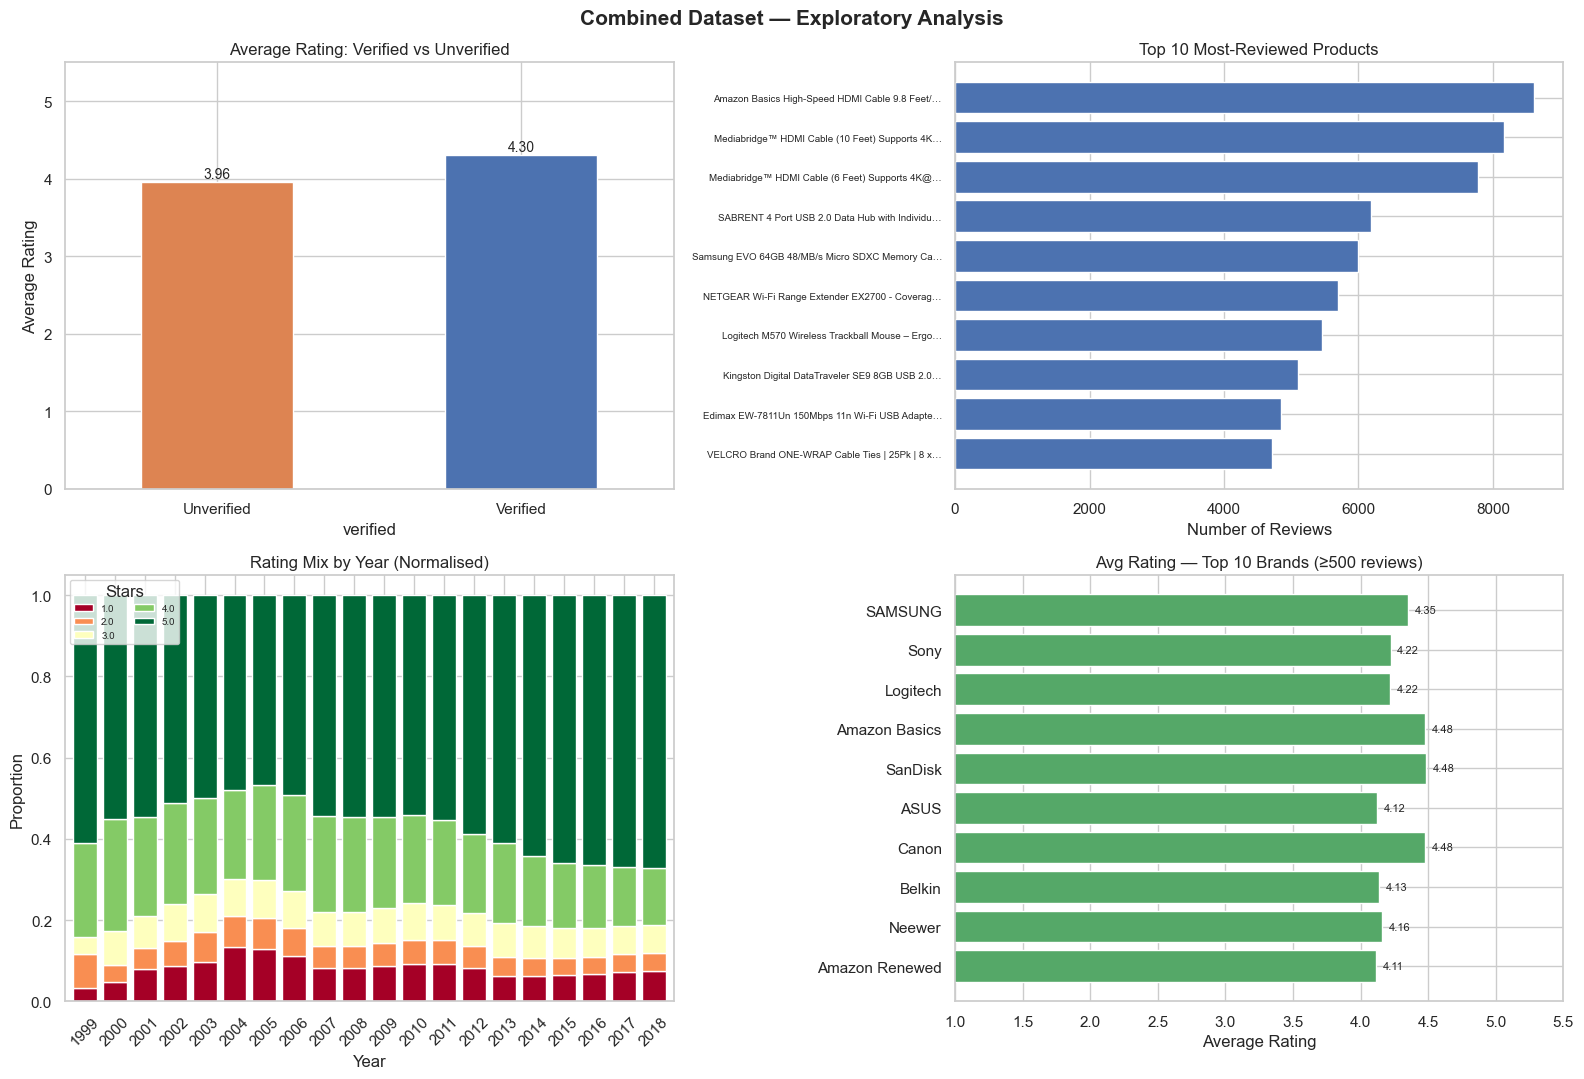

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Derive year locally — df_merged doesn't have it yet (added in Step 13)
year_series = pd.to_datetime(df_merged["unixReviewTime"], unit="s").dt.year

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Combined Dataset — Exploratory Analysis", fontsize=15, fontweight="bold")

# 1. Average rating: verified vs unverified
avg_by_verified = (
    df_merged.groupby("verified")["overall"]
    .mean()
    .rename(index={True: "Verified", False: "Unverified"})
)
avg_by_verified.plot(kind="bar", ax=axes[0, 0], color=["#DD8452", "#4C72B0"], rot=0)
axes[0, 0].set_title("Average Rating: Verified vs Unverified")
axes[0, 0].set_ylabel("Average Rating")
axes[0, 0].set_ylim(0, 5.5)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.2f}",
                        (p.get_x() + p.get_width() / 2, p.get_height() + 0.05),
                        ha="center", fontsize=10)

# 2. Top 10 most-reviewed products
title_col = next((c for c in df_merged.columns if c.lower() == "title"), "asin")
top_products = df_merged.groupby(title_col).size().nlargest(10)
labels = [str(t)[:45] + "…" if len(str(t)) > 45 else str(t) for t in top_products.index[::-1]]
axes[0, 1].barh(labels, top_products.values[::-1], color="#4C72B0")
axes[0, 1].set_title("Top 10 Most-Reviewed Products")
axes[0, 1].set_xlabel("Number of Reviews")
axes[0, 1].tick_params(axis="y", labelsize=7)

# 3. Normalised rating mix by year
pivot_df = df_merged.copy()
pivot_df["year"] = year_series.values
pivot = pivot_df.groupby(["year", "overall"]).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm.plot(kind="bar", stacked=True, ax=axes[1, 0], colormap="RdYlGn", width=0.8)
axes[1, 0].set_title("Rating Mix by Year (Normalised)")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(title="Stars", loc="upper left", fontsize=7, ncol=2)

# 4. Average rating by brand (top 10 by volume)
brand_col = next((c for c in df_merged.columns if c.lower() == "brand"), None)
if brand_col:
    brand_stats = (
        df_merged.groupby(brand_col)
        .agg(count=("overall", "size"), avg_rating=("overall", "mean"))
        .query("count >= 500")
        .nlargest(10, "count")
    )
    axes[1, 1].barh(brand_stats.index[::-1], brand_stats["avg_rating"][::-1], color="#55A868")
    axes[1, 1].set_title("Avg Rating — Top 10 Brands (≥500 reviews)")
    axes[1, 1].set_xlabel("Average Rating")
    axes[1, 1].set_xlim(1, 5.5)
    for i, (_, row) in enumerate(brand_stats[::-1].iterrows()):
        axes[1, 1].text(row["avg_rating"] + 0.05, i, f"{row['avg_rating']:.2f}", va="center", fontsize=8)
else:
    axes[1, 1].text(0.5, 0.5, "No 'brand' column in merged data", ha="center", va="center",
                    transform=axes[1, 1].transAxes)
    axes[1, 1].set_title("Brand Analysis")

plt.tight_layout()
plt.show()

## Step 13: Feature Engineering for NLP

Build a clean, feature-rich DataFrame (`df_nlp`) ready for downstream NLP tasks — sentiment analysis, topic modelling, text classification, etc.

| Feature | Description |
|---|---|
| `clean_text` | Lowercased, HTML-stripped, punctuation-normalised `reviewText` |
| `combined_text` | `summary` + `reviewText` joined — richer context for embeddings |
| `char_count` | Raw character length of `reviewText` |
| `word_count` | Token count of cleaned review |
| `avg_word_len` | Average token length (vocabulary complexity proxy) |
| `vote_count` | Numeric helpfulness votes (NaN → 0) |
| `is_verified` | Verified purchase cast to 0/1 int |
| `year` / `month` | Time features from unix timestamp |
| `review_age_days` | Days since review (relative to latest review in dataset) |
| `sentiment_label` | `positive` (4–5★) · `neutral` (3★) · `negative` (1–2★) |

In [7]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)         # strip HTML tags
    text = re.sub(r"[^\w\s']", " ", text)         # keep word chars, spaces, apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df_nlp = df_merged.copy()

# --- Text features ---
df_nlp["clean_text"]     = df_nlp["reviewText"].apply(clean_text)
df_nlp["combined_text"]  = (
    df_nlp["summary"].fillna("") + " " + df_nlp["reviewText"].fillna("")
).str.strip().apply(clean_text)
df_nlp["char_count"]     = df_nlp["reviewText"].fillna("").str.len()
df_nlp["word_count"]     = df_nlp["clean_text"].str.split().str.len().fillna(0).astype(int)
df_nlp["avg_word_len"]   = df_nlp["clean_text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.strip() else 0
)

# --- Engagement features ---
df_nlp["vote_count"]     = pd.to_numeric(df_nlp["vote"], errors="coerce").fillna(0).astype(int)
df_nlp["is_verified"]    = df_nlp["verified"].astype(int)

# --- Time features ---
review_dt                = pd.to_datetime(df_nlp["unixReviewTime"], unit="s")
df_nlp["year"]           = review_dt.dt.year
df_nlp["month"]          = review_dt.dt.month
max_ts                   = df_nlp["unixReviewTime"].max()
df_nlp["review_age_days"] = ((max_ts - df_nlp["unixReviewTime"]) / 86400).astype(int)

# --- Sentiment label (3-class) ---
df_nlp["sentiment_label"] = df_nlp["overall"].map(
    lambda r: "positive" if r >= 4 else ("neutral" if r == 3 else "negative")
)

# Drop columns not useful for NLP
drop_cols = [c for c in ["style", "image", "reviewTime", "vote"] if c in df_nlp.columns]
df_nlp.drop(columns=drop_cols, inplace=True)

print("=== NLP-Ready DataFrame ===")
print(f"Shape: {df_nlp.shape}")
print(f"\nEngineered features:")
eng_cols = ["clean_text", "combined_text", "char_count", "word_count", "avg_word_len",
            "vote_count", "is_verified", "year", "month", "review_age_days", "sentiment_label"]
for col in eng_cols:
    print(f"  {col:<22} dtype={df_nlp[col].dtype}")

print("\nSentiment label distribution:")
print(df_nlp["sentiment_label"].value_counts().rename("count").to_frame()
      .assign(pct=lambda x: (x["count"] / len(df_nlp) * 100).round(1)).to_string())

print("\nWord count statistics (reviewText):")
print(df_nlp["word_count"].describe().round(1).to_string())

# Sample row
sample = df_nlp[df_nlp["word_count"] > 20].iloc[0]
print(f"\nSample NLP-ready row:")
print(f"  Rating        : {sample['overall']}")
print(f"  Sentiment     : {sample['sentiment_label']}")
print(f"  Word count    : {sample['word_count']}")
print(f"  Clean text    : {sample['clean_text'][:120]}…")
if "title" in df_nlp.columns:
    print(f"  Product title : {str(sample['title'])[:80]}")

=== NLP-Ready DataFrame ===
Shape: (6739590, 25)

Engineered features:
  clean_text             dtype=str
  combined_text          dtype=str
  char_count             dtype=int64
  word_count             dtype=int64
  avg_word_len           dtype=float64
  vote_count             dtype=int64
  is_verified            dtype=int64
  year                   dtype=int32
  month                  dtype=int32
  review_age_days        dtype=int64
  sentiment_label        dtype=str

Sentiment label distribution:
                   count   pct
sentiment_label               
positive         5460975  81.0
negative          773834  11.5
neutral           504781   7.5

Word count statistics (reviewText):
count    6739590.0
mean          65.7
std          118.0
min            0.0
25%           10.0
50%           29.0
75%           72.0
max         6355.0

Sample NLP-ready row:
  Rating        : 5.0
  Sentiment     : positive
  Word count    : 183
  Clean text    : this is the best novel i have read in 2

In [8]:
nlp_csv_path = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_nlp_ready.csv"
df_nlp.to_csv(nlp_csv_path, index=False)
print(f"✓ NLP-ready DataFrame saved to:")
print(f"  {nlp_csv_path}")
print(f"  Size: {os.path.getsize(nlp_csv_path) / (1024**2):.1f} MB")
print(f"\nQuick-load in future sessions:")
print(f"  df_nlp = pd.read_csv('{nlp_csv_path}', low_memory=False)")

✓ NLP-ready DataFrame saved to:
  /Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_nlp_ready.csv
  Size: 8449.5 MB

Quick-load in future sessions:
  df_nlp = pd.read_csv('/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_nlp_ready.csv', low_memory=False)


## Section 1 — Rating Inflation Over Time

Uses `df_nlp` (inherits `overall` and `year` from the merged + feature-engineered data).

- Average rating per year with per-year annotations and peak marker  
- Improved normalised stacked bar: 1★–5★ composition per year with 5★ annotation on the latest year

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_26093/56780504.py:67: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/shashikamihiranga/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


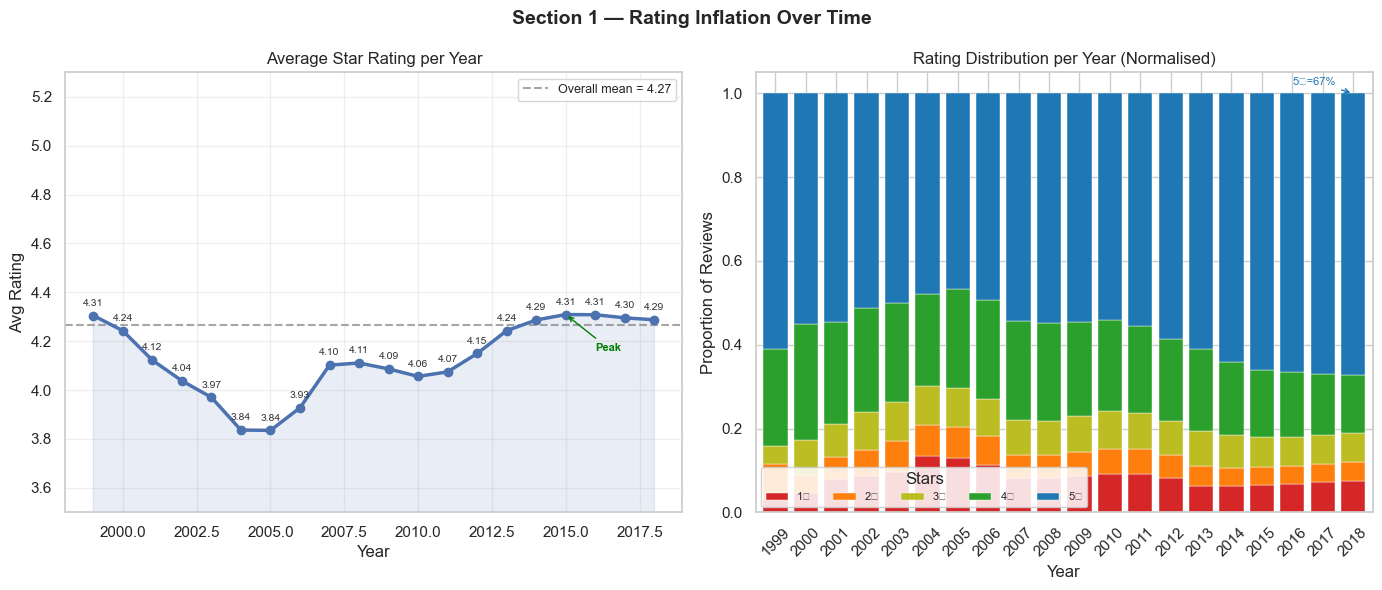

=== Section 1: Rating Inflation Summary ===
Year range         : 1999 – 2018
Earliest year avg  : 4.305  (1999)
Latest year avg    : 4.288  (2018)
Overall mean       : 4.268
Peak year          : 2015  avg=4.309  n=1,441,804
Lowest year        : 2005  avg=3.835
Rating drift       : -0.017 stars  (downward trend)


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
star_colors = ["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#1f77b4"]

# Ensure year column exists (df_nlp always has it, but guard for safety)
if "year" not in df_nlp.columns:
    df_nlp["year"] = pd.to_datetime(df_nlp["unixReviewTime"], unit="s").dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Section 1 — Rating Inflation Over Time", fontsize=14, fontweight="bold")

# 1a. Average rating per year with annotated trend line
yearly = (
    df_nlp.groupby("year")["overall"]
    .agg(mean="mean", count="count")
    .reset_index()
)
peak_row = yearly.loc[yearly["mean"].idxmax()]
low_row  = yearly.loc[yearly["mean"].idxmin()]

axes[0].plot(yearly["year"], yearly["mean"], marker="o", linewidth=2.5,
             color="#4C72B0", zorder=3)
axes[0].fill_between(yearly["year"], yearly["mean"], alpha=0.12, color="#4C72B0")
axes[0].axhline(df_nlp["overall"].mean(), linestyle="--", color="gray", alpha=0.7,
                label=f"Overall mean = {df_nlp['overall'].mean():.2f}")

for _, row in yearly.iterrows():
    axes[0].annotate(f"{row['mean']:.2f}", (row["year"], row["mean"]),
                     textcoords="offset points", xytext=(0, 7),
                     ha="center", fontsize=7.5, color="#333")
axes[0].annotate("Peak", xy=(peak_row["year"], peak_row["mean"]),
                 xytext=(peak_row["year"] + 1, peak_row["mean"] - 0.15),
                 fontsize=8, color="green", fontweight="bold",
                 arrowprops={"arrowstyle": "->", "color": "green"})
axes[0].set_title("Average Star Rating per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Avg Rating")
axes[0].set_ylim(3.5, 5.3)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 1b. Normalised stacked bar — improved version of Step 12's rating mix
pivot = df_nlp.groupby(["year", "overall"]).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm.plot(kind="bar", stacked=True, ax=axes[1],
                color=star_colors, width=0.8, edgecolor="white", linewidth=0.3)
axes[1].set_title("Rating Distribution per Year (Normalised)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Proportion of Reviews")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Stars", labels=["1★", "2★", "3★", "4★", "5★"],
               loc="lower left", fontsize=8, ncol=5, framealpha=0.85)
axes[1].set_ylim(0, 1.05)
# Annotate 5-star proportion for the most recent year
last_yr = pivot_norm.index[-1]
five_star_pct = pivot_norm.loc[last_yr, 5.0] * 100
axes[1].annotate(f"5★={five_star_pct:.0f}%",
                 xy=(len(pivot_norm) - 1, 1.0),
                 xytext=(len(pivot_norm) - 3, 1.02),
                 fontsize=8, color="#1f77b4",
                 arrowprops={"arrowstyle": "->", "color": "#1f77b4"})

plt.tight_layout()
plt.show()

print("=== Section 1: Rating Inflation Summary ===")
print(f"Year range         : {int(yearly['year'].min())} – {int(yearly['year'].max())}")
print(f"Earliest year avg  : {yearly.iloc[0]['mean']:.3f}  ({int(yearly.iloc[0]['year'])})")
print(f"Latest year avg    : {yearly.iloc[-1]['mean']:.3f}  ({int(yearly.iloc[-1]['year'])})")
print(f"Overall mean       : {df_nlp['overall'].mean():.3f}")
print(f"Peak year          : {int(peak_row['year'])}  avg={peak_row['mean']:.3f}  "
      f"n={int(peak_row['count']):,}")
print(f"Lowest year        : {int(low_row['year'])}  avg={low_row['mean']:.3f}")
delta = yearly.iloc[-1]["mean"] - yearly.iloc[0]["mean"]
print(f"Rating drift       : {delta:+.3f} stars  ({'upward' if delta > 0 else 'downward'} trend)")

## Section 2 — Reviewer Behavior

Uses `df_nlp` (has `reviewerID`, `overall`, `is_verified`).

- Reviews per reviewer distribution (log-log) — shows the power-law tail of super-reviewers  
- Top 20 most active reviewers, coloured by avg rating they give  
- Single-review vs repeat reviewer rating density comparison  
- Verified purchase rate by activity bucket (1, 2–5, 6–20, 20+)

/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_26093/244639516.py:90: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/shashikamihiranga/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


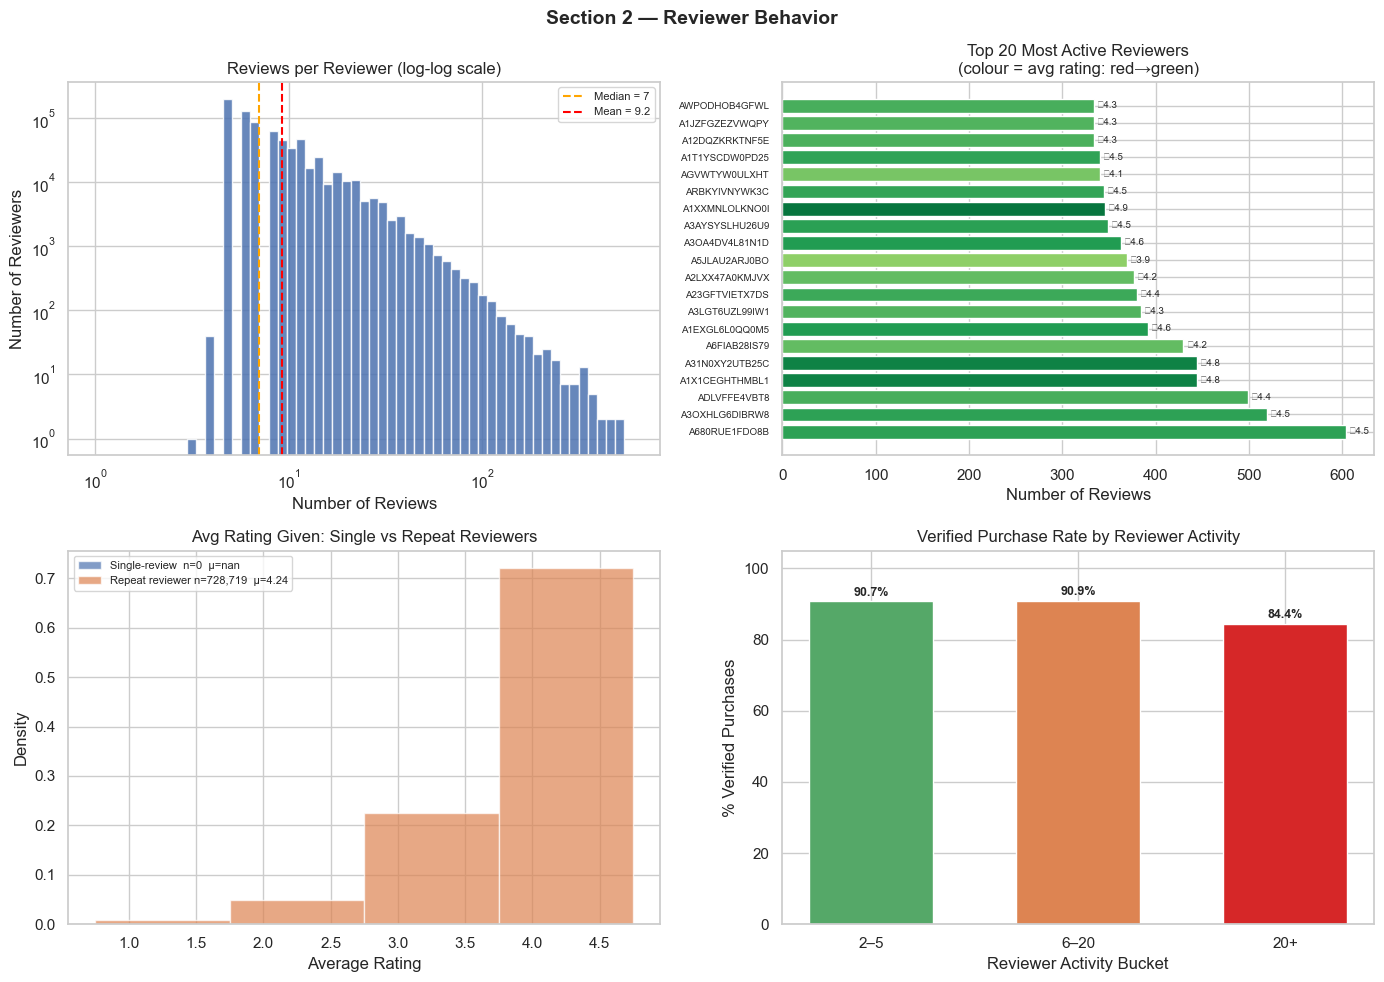

=== Section 2: Reviewer Behavior Summary ===
Unique reviewers           : 728,719
Single-review reviewers    : 0  (0.0%)
Repeat reviewers (≥2)      : 728,719  (100.0%)
Max reviews by one person  : 604
Avg rating — single-review : nan
Avg rating — repeat        : 4.240

Verified purchase rate by activity bucket:
  1 review    : nan%
  2–5         : 90.7%
  6–20        : 90.9%
  20+         : 84.4%


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

# Reviewer-level aggregation
reviewer_stats = (
    df_nlp.groupby("reviewerID")
    .agg(
        review_count=("overall", "size"),
        avg_rating=("overall", "mean"),
        verified_rate=("is_verified", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 2 — Reviewer Behavior", fontsize=14, fontweight="bold")

# 2a. Reviews per reviewer distribution (log-log)
rc = reviewer_stats["review_count"]
axes[0, 0].hist(rc, bins=np.logspace(0, np.log10(rc.max()), 60),
                color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Reviews per Reviewer (log-log scale)")
axes[0, 0].set_xlabel("Number of Reviews")
axes[0, 0].set_ylabel("Number of Reviewers")
axes[0, 0].axvline(rc.median(), color="orange", linestyle="--",
                   label=f"Median = {rc.median():.0f}")
axes[0, 0].axvline(rc.mean(), color="red", linestyle="--",
                   label=f"Mean = {rc.mean():.1f}")
axes[0, 0].legend(fontsize=8)

# 2b. Top 20 most active reviewers, coloured by avg rating
top20 = reviewer_stats.nlargest(20, "review_count")
bar_colors20 = [plt.cm.RdYlGn((r - 1) / 4) for r in top20["avg_rating"]]
axes[0, 1].barh(range(20), top20["review_count"].values,
                color=bar_colors20, edgecolor="white")
axes[0, 1].set_yticks(range(20))
axes[0, 1].set_yticklabels(
    [rid[:14] + "…" if len(rid) > 14 else rid for rid in top20["reviewerID"]],
    fontsize=7)
axes[0, 1].set_title("Top 20 Most Active Reviewers\n(colour = avg rating: red→green)")
axes[0, 1].set_xlabel("Number of Reviews")
for i, row in enumerate(top20.itertuples()):
    axes[0, 1].text(row.review_count + 3, i,
                    f"★{row.avg_rating:.1f}", va="center", fontsize=7)

# 2c. Single vs repeat reviewer avg rating distribution (density)
single = reviewer_stats[reviewer_stats["review_count"] == 1]["avg_rating"]
repeat = reviewer_stats[reviewer_stats["review_count"]  > 1]["avg_rating"]
bins = np.arange(0.75, 5.75, 1)
axes[1, 0].hist(single, bins=bins, alpha=0.7, color="#4C72B0", density=True,
                label=f"Single-review  n={len(single):,}  μ={single.mean():.2f}")
axes[1, 0].hist(repeat, bins=bins, alpha=0.7, color="#DD8452", density=True,
                label=f"Repeat reviewer n={len(repeat):,}  μ={repeat.mean():.2f}")
axes[1, 0].set_title("Avg Rating Given: Single vs Repeat Reviewers")
axes[1, 0].set_xlabel("Average Rating")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend(fontsize=8)

# 2d. Verified purchase rate by activity bucket
def activity_bucket(n):
    if n == 1:    return "1 review"
    elif n <= 5:  return "2–5"
    elif n <= 20: return "6–20"
    else:         return "20+"

bucket_order = ["1 review", "2–5", "6–20", "20+"]
reviewer_stats["bucket"] = reviewer_stats["review_count"].apply(activity_bucket)
bucket_map = reviewer_stats.set_index("reviewerID")["bucket"]
df_nlp["_bucket"] = df_nlp["reviewerID"].map(bucket_map)
vr_bucket = df_nlp.groupby("_bucket")["is_verified"].mean().reindex(bucket_order) * 100
df_nlp.drop(columns=["_bucket"], inplace=True)

bucket_colors = ["#4C72B0", "#55A868", "#DD8452", "#d62728"]
bars = axes[1, 1].bar(bucket_order, vr_bucket.values,
                      color=bucket_colors, edgecolor="white", width=0.6)
axes[1, 1].set_title("Verified Purchase Rate by Reviewer Activity")
axes[1, 1].set_xlabel("Reviewer Activity Bucket")
axes[1, 1].set_ylabel("% Verified Purchases")
axes[1, 1].set_ylim(0, 105)
for bar, v in zip(bars, vr_bucket.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                    f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("=== Section 2: Reviewer Behavior Summary ===")
print(f"Unique reviewers           : {len(reviewer_stats):,}")
print(f"Single-review reviewers    : {(rc == 1).sum():,}  ({(rc == 1).mean()*100:.1f}%)")
print(f"Repeat reviewers (≥2)      : {(rc > 1).sum():,}  ({(rc > 1).mean()*100:.1f}%)")
print(f"Max reviews by one person  : {rc.max():,}")
print(f"Avg rating — single-review : {single.mean():.3f}")
print(f"Avg rating — repeat        : {repeat.mean():.3f}")
print(f"\nVerified purchase rate by activity bucket:")
for b in bucket_order:
    print(f"  {b:<12}: {vr_bucket[b]:.1f}%")

## Section 3 — Review Text Quality

Uses `df_nlp` which has pre-computed `word_count` and `vote_count` columns.

- Word count distribution per star rating (boxplot, clipped at 500 words)  
- Average review length trend over years  
- Helpfulness votes vs word count scatter (50k sample, coloured by rating)  
- % of short reviews (< 10 words) per star rating

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_26093/663991527.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 0].boxplot(
/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_26093/663991527.py:65: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/shashikamihiranga/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


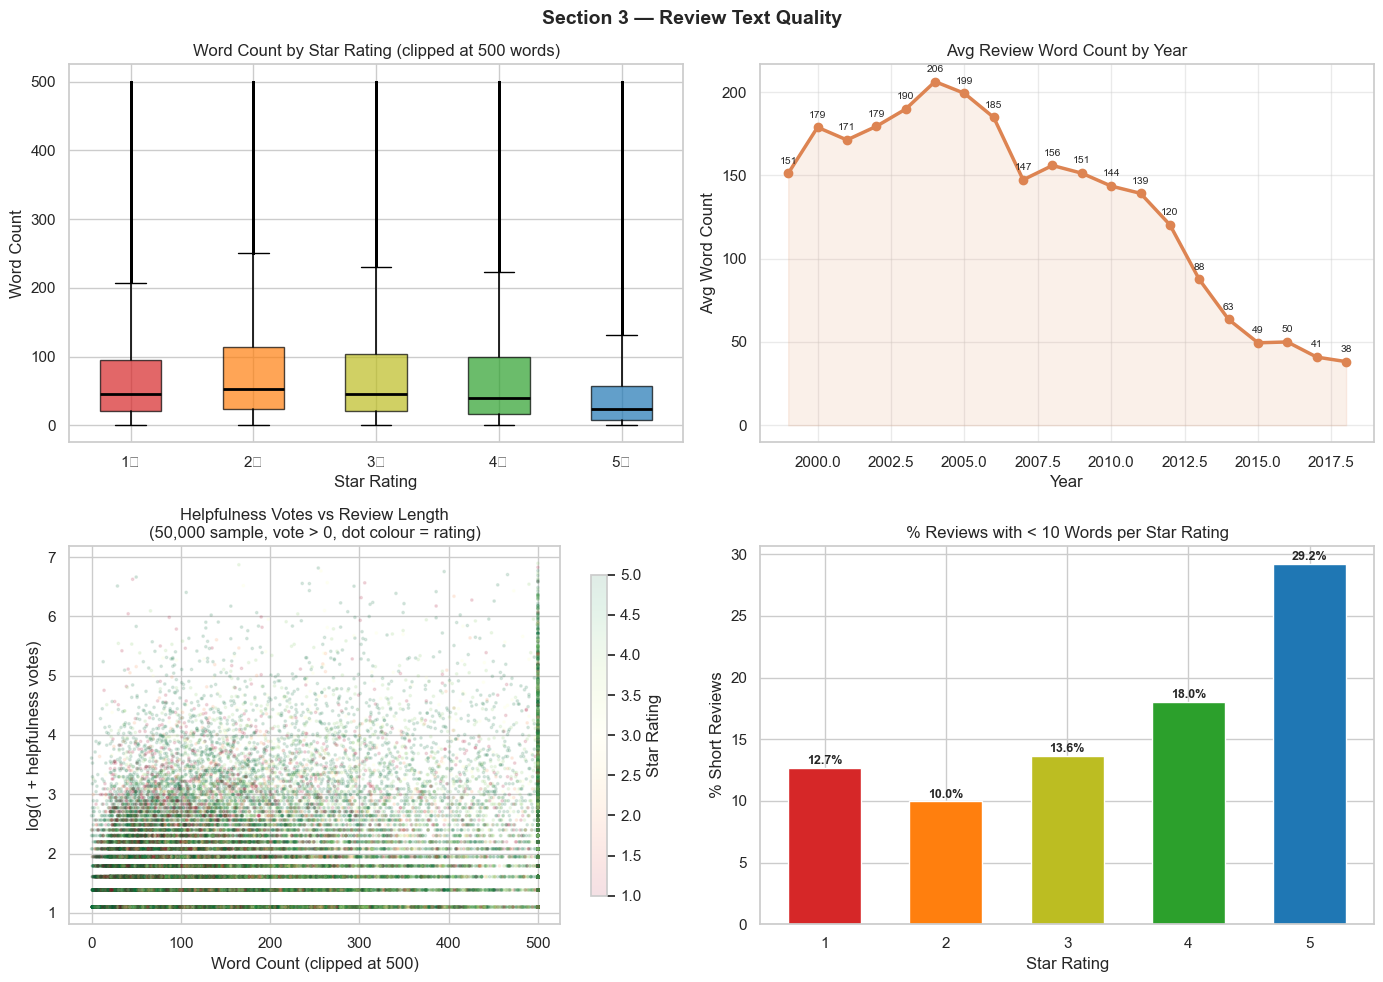

=== Section 3: Review Text Quality Summary ===
Overall median word count : 29
  1★  median=45  mean=79  short(<10 words)=12.7%
  2★  median=53  mean=94  short(<10 words)=10.0%
  3★  median=45  mean=89  short(<10 words)=13.6%
  4★  median=40  mean=88  short(<10 words)=18.0%
  5★  median=24  mean=54  short(<10 words)=29.2%

Reviews with helpfulness votes : 948,320  (14.1%)
Max helpfulness votes          : 999


In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
star_colors = ["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#1f77b4"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 3 — Review Text Quality", fontsize=14, fontweight="bold")

# 3a. Word count distribution by star rating (boxplot, clipped at 500)
wc_by_star = [df_nlp[df_nlp["overall"] == s]["word_count"].clip(0, 500).values
              for s in [1.0, 2.0, 3.0, 4.0, 5.0]]
bp = axes[0, 0].boxplot(
    wc_by_star, labels=["1★", "2★", "3★", "4★", "5★"], patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    whiskerprops={"linewidth": 1.2},
    flierprops={"markersize": 1, "alpha": 0.3}
)
for patch, color in zip(bp["boxes"], star_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 0].set_title("Word Count by Star Rating (clipped at 500 words)")
axes[0, 0].set_xlabel("Star Rating")
axes[0, 0].set_ylabel("Word Count")

# 3b. Average review length trend over years
wc_by_year = df_nlp.groupby("year")["word_count"].mean()
axes[0, 1].plot(wc_by_year.index, wc_by_year.values, marker="o", linewidth=2.5, color="#DD8452")
axes[0, 1].fill_between(wc_by_year.index, wc_by_year.values, alpha=0.12, color="#DD8452")
for yr, wc in wc_by_year.items():
    axes[0, 1].annotate(f"{wc:.0f}", (yr, wc),
                        textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7.5)
axes[0, 1].set_title("Avg Review Word Count by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Avg Word Count")
axes[0, 1].grid(True, alpha=0.4)

# 3c. Helpfulness votes vs word count scatter (50k sample, vote_count > 0)
has_votes = df_nlp[df_nlp["vote_count"] > 0]
samp = has_votes.sample(min(50_000, len(has_votes)), random_state=42)
sc = axes[1, 0].scatter(
    samp["word_count"].clip(0, 500), np.log1p(samp["vote_count"]),
    alpha=0.12, s=3, c=samp["overall"], cmap="RdYlGn",
    vmin=1, vmax=5, rasterized=True
)
axes[1, 0].set_title(f"Helpfulness Votes vs Review Length\n({len(samp):,} sample, vote > 0, dot colour = rating)")
axes[1, 0].set_xlabel("Word Count (clipped at 500)")
axes[1, 0].set_ylabel("log(1 + helpfulness votes)")
plt.colorbar(sc, ax=axes[1, 0], label="Star Rating", shrink=0.85)

# 3d. % of short reviews (< 10 words) per star rating
short_pct = df_nlp.groupby("overall").apply(lambda g: (g["word_count"] < 10).mean() * 100)
bars = axes[1, 1].bar(short_pct.index.astype(int), short_pct.values,
                      color=star_colors, edgecolor="white", width=0.6)
axes[1, 1].set_title("% Reviews with < 10 Words per Star Rating")
axes[1, 1].set_xlabel("Star Rating")
axes[1, 1].set_ylabel("% Short Reviews")
axes[1, 1].set_xticks([1, 2, 3, 4, 5])
for bar, v in zip(bars, short_pct.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                    f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("=== Section 3: Review Text Quality Summary ===")
print(f"Overall median word count : {df_nlp['word_count'].median():.0f}")
for s in [1.0, 2.0, 3.0, 4.0, 5.0]:
    sub = df_nlp[df_nlp["overall"] == s]
    print(f"  {int(s)}★  median={sub['word_count'].median():.0f}  "
          f"mean={sub['word_count'].mean():.0f}  "
          f"short(<10 words)={( sub['word_count'] < 10).mean()*100:.1f}%")
print(f"\nReviews with helpfulness votes : {(df_nlp['vote_count'] > 0).sum():,}  "
      f"({(df_nlp['vote_count'] > 0).mean()*100:.1f}%)")
print(f"Max helpfulness votes          : {df_nlp['vote_count'].max():,}")

## Section 4 — Product Analysis

Uses `df_nlp` for product-level aggregation (same `asin`, `overall`, `title` as `df_merged`).

- Avg rating vs review count scatter (log scale, top 5,000 products)  
- Products with highest rating variance (≥50 reviews) — identifies polarising products  
- Top 10 most-reviewed products (improved — colour-coded by avg rating)

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_26093/2613444148.py:75: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_26093/2613444148.py:75: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_26093/2613444148.py:75: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/shashikamihiranga/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/shashikamihiranga/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/shashikamihiranga/Library/Python/3

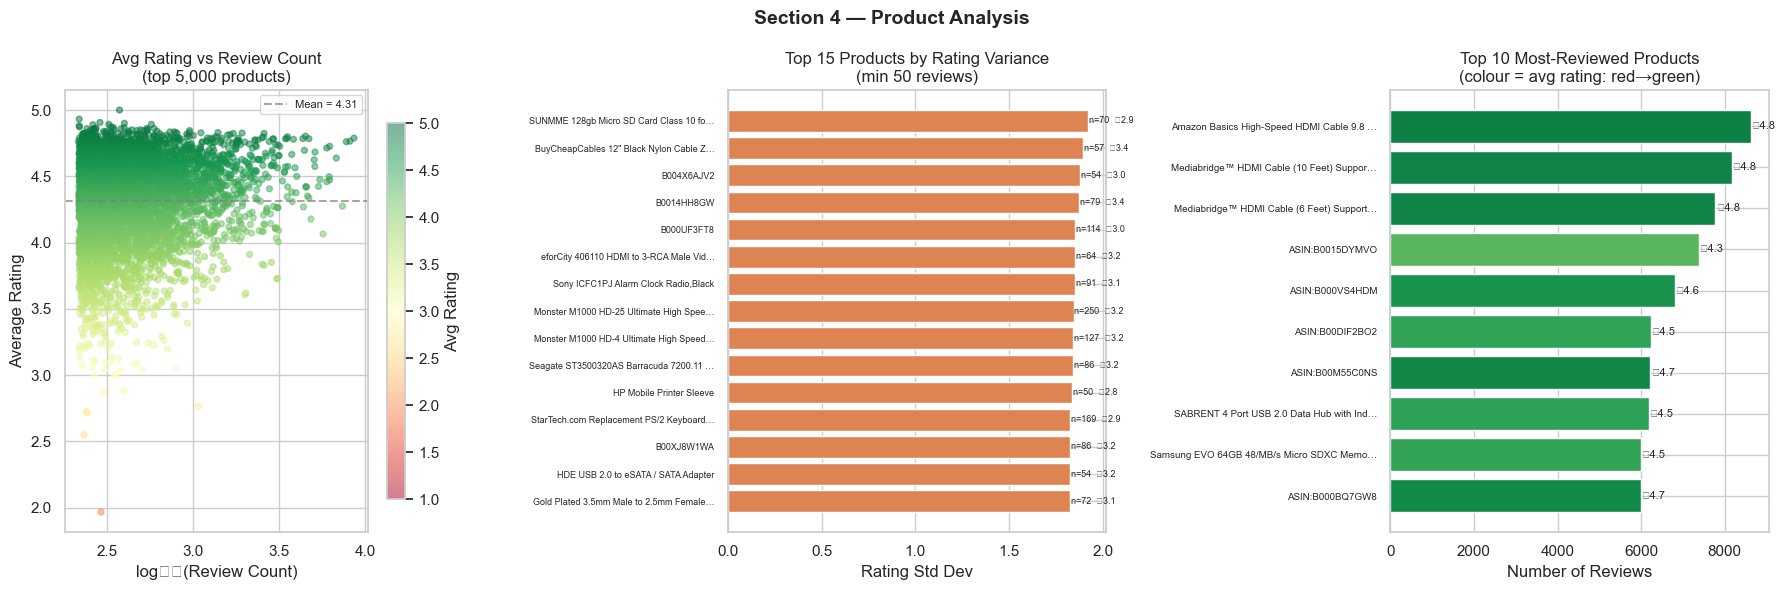

=== Section 4: Product Analysis Summary ===
Unique products           : 160,052
Products with ≥50 reviews : 25,275
Mean reviews per product  : 42.1
Median reviews per product: 13
Max reviews (1 product)   : 8,617

Top 5 highest-variance products (min 50 reviews):
  std=1.92  avg=★2.9  n=70  — SUNMME 128gb Micro SD Card Class 10 for Samsung Ga
  std=1.90  avg=★3.4  n=57  — BuyCheapCables 12" Black Nylon Cable Zip Ties Self
  std=1.88  avg=★3.0  n=54  — B004X6AJV2
  std=1.87  avg=★3.4  n=79  — B0014HH8GW
  std=1.85  avg=★3.0  n=114  — B000UF3FT8


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
star_colors = ["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#1f77b4"]

# Product-level aggregation from df_nlp (same asin/overall/title as df_merged)
product_stats = (
    df_nlp.groupby("asin")
    .agg(
        review_count=("overall", "size"),
        avg_rating=("overall", "mean"),
        rating_std=("overall", "std"),
        title=("title", "first")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Section 4 — Product Analysis", fontsize=14, fontweight="bold")

# 4a. Avg rating vs review count (top 5,000 products, log x-axis)
top5k = product_stats.nlargest(5000, "review_count").copy()
sc = axes[0].scatter(
    np.log10(top5k["review_count"].clip(lower=1)),
    top5k["avg_rating"],
    c=top5k["avg_rating"], cmap="RdYlGn", alpha=0.5, s=18,
    vmin=1, vmax=5, rasterized=True
)
plt.colorbar(sc, ax=axes[0], label="Avg Rating", shrink=0.85)
axes[0].axhline(top5k["avg_rating"].mean(), linestyle="--", color="gray", alpha=0.7,
                label=f"Mean = {top5k['avg_rating'].mean():.2f}")
axes[0].set_title("Avg Rating vs Review Count\n(top 5,000 products)")
axes[0].set_xlabel("log₁₀(Review Count)")
axes[0].set_ylabel("Average Rating")
axes[0].legend(fontsize=8)

# 4b. Products with highest rating variance (min 50 reviews)
high_var = (
    product_stats[product_stats["review_count"] >= 50]
    .nlargest(15, "rating_std")
)
var_labels = [
    (str(t)[:38] + "…") if pd.notna(t) and len(str(t)) > 38 else
    (str(t) if pd.notna(t) else a[:12])
    for t, a in zip(high_var["title"], high_var["asin"])
]
axes[1].barh(var_labels[::-1], high_var["rating_std"].values[::-1],
             color="#DD8452", edgecolor="white")
axes[1].set_title("Top 15 Products by Rating Variance\n(min 50 reviews)")
axes[1].set_xlabel("Rating Std Dev")
axes[1].tick_params(axis="y", labelsize=6.5)
for i, row in enumerate(high_var[::-1].itertuples()):
    axes[1].text(row.rating_std + 0.005, i,
                 f"n={row.review_count:,}  ★{row.avg_rating:.1f}", va="center", fontsize=6.5)

# 4c. Top 10 most-reviewed products (colour = avg rating)
top10 = product_stats.nlargest(10, "review_count")
top10_labels = [
    (str(t)[:40] + "…") if pd.notna(t) and len(str(t)) > 40 else
    (str(t) if pd.notna(t) else f"ASIN:{a[:10]}")
    for t, a in zip(top10["title"], top10["asin"])
]
bar_colors10 = [plt.cm.RdYlGn((r - 1) / 4) for r in top10["avg_rating"]]
axes[2].barh(top10_labels[::-1], top10["review_count"].values[::-1],
             color=bar_colors10[::-1], edgecolor="white")
axes[2].set_title("Top 10 Most-Reviewed Products\n(colour = avg rating: red→green)")
axes[2].set_xlabel("Number of Reviews")
axes[2].tick_params(axis="y", labelsize=7)
for i, row in enumerate(top10[::-1].itertuples()):
    axes[2].text(row.review_count + 20, i, f"★{row.avg_rating:.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("=== Section 4: Product Analysis Summary ===")
print(f"Unique products           : {len(product_stats):,}")
print(f"Products with ≥50 reviews : {(product_stats['review_count'] >= 50).sum():,}")
print(f"Mean reviews per product  : {product_stats['review_count'].mean():.1f}")
print(f"Median reviews per product: {product_stats['review_count'].median():.0f}")
print(f"Max reviews (1 product)   : {product_stats['review_count'].max():,}")
print(f"\nTop 5 highest-variance products (min 50 reviews):")
for row in high_var.head(5).itertuples():
    title_s = str(row.title)[:50] if pd.notna(row.title) else row.asin
    print(f"  std={row.rating_std:.2f}  avg=★{row.avg_rating:.1f}  n={row.review_count:,}  — {title_s}")

## Section 5 — Sentiment vs Rating

Uses `df_nlp` which has `sentiment_label` (positive / neutral / negative), `word_count`, and `is_verified`.

- Bar chart of sentiment label counts and percentages  
- Heatmap cross-tab: sentiment label vs verified purchase  
- Average word count per sentiment class

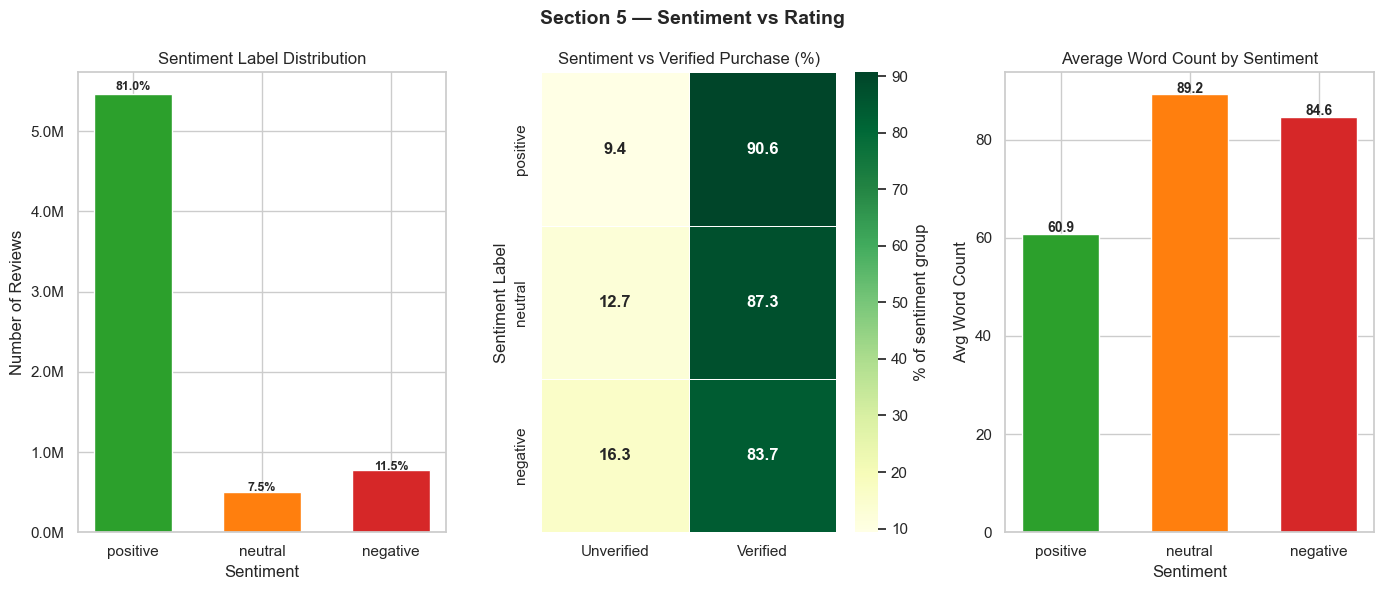

=== Section 5: Sentiment Summary ===
  positive  :  5,460,975 reviews  |  90.6% verified  |  60.9 avg words
  neutral   :    504,781 reviews  |  87.3% verified  |  89.2 avg words
  negative  :    773,834 reviews  |  83.7% verified  |  84.6 avg words


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
sent_colors = {"positive": "#2ca02c", "neutral": "#ff7f0e", "negative": "#d62728"}
sent_order  = ["positive", "neutral", "negative"]

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle("Section 5 — Sentiment vs Rating", fontsize=14, fontweight="bold")

# 5a. Sentiment label distribution
sent_counts = df_nlp["sentiment_label"].value_counts().reindex(sent_order)
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[sent_colors[s] for s in sent_order], edgecolor="white", width=0.6)
axes[0].set_title("Sentiment Label Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Reviews")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, v in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v * 1.01,
                 f"{v / len(df_nlp) * 100:.1f}%", ha="center", fontsize=9, fontweight="bold")

# 5b. Cross-tab heatmap: sentiment vs verified purchase
ct = pd.crosstab(
    pd.Categorical(df_nlp["sentiment_label"], categories=sent_order, ordered=True),
    df_nlp["is_verified"].map({1: "Verified", 0: "Unverified"}),
    normalize="index"
) * 100
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlGn", ax=axes[1],
            annot_kws={"size": 12, "weight": "bold"},
            cbar_kws={"label": "% of sentiment group"}, linewidths=0.5)
axes[1].set_title("Sentiment vs Verified Purchase (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Sentiment Label")
axes[1].tick_params(axis="x", rotation=0)

# 5c. Average word count by sentiment
wc_sent = df_nlp.groupby("sentiment_label")["word_count"].mean().reindex(sent_order)
axes[2].bar(wc_sent.index, wc_sent.values,
            color=[sent_colors[s] for s in sent_order], edgecolor="white", width=0.6)
axes[2].set_title("Average Word Count by Sentiment")
axes[2].set_xlabel("Sentiment")
axes[2].set_ylabel("Avg Word Count")
for i, (s, wc) in enumerate(wc_sent.items()):
    axes[2].text(i, wc + 0.3, f"{wc:.1f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print("=== Section 5: Sentiment Summary ===")
for s in sent_order:
    n  = (df_nlp["sentiment_label"] == s).sum()
    vr = df_nlp[df_nlp["sentiment_label"] == s]["is_verified"].mean() * 100
    wc = df_nlp[df_nlp["sentiment_label"] == s]["word_count"].mean()
    print(f"  {s:<10}: {n:>10,} reviews  |  {vr:.1f}% verified  |  {wc:.1f} avg words")

## Step 14: Enhanced Text Cleaning — Stopword & Digit Removal

Improve `clean_text` by removing English stopwords and standalone digits, then quantify the vocabulary reduction.

- **Digit removal**: strip standalone numbers (`\b\d+\b`) that carry no semantic signal
- **Stopword removal**: apply NLTK English stopwords → new column `clean_text_nostop`
- **Updated counts**: `word_count` (with stopwords) and `word_count_nostop` (without)
- **Vocabulary comparison**: CountVectorizer on 100 k sample, before vs after

In [14]:
import re
import nltk
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))

# ── 1. Vectorised digit removal on clean_text ───────────────────────────────────────
print("Removing standalone digits from clean_text …")
df_nlp["clean_text"] = (df_nlp["clean_text"]
                         .str.replace(r"\b\d+\b", " ", regex=True)
                         .str.strip())

# ── 2. Stopword removal → new column clean_text_nostop ─────────────────────────────
def _remove_stopwords(text):
    if not isinstance(text, str) or text == "":
        return ""
    return " ".join(w for w in text.split() if w not in STOP_WORDS)

print("Building clean_text_nostop (∼1–2 min for 6.7 M rows) …")
df_nlp["clean_text_nostop"] = df_nlp["clean_text"].apply(_remove_stopwords)

# ── 3. Update word counts ──────────────────────────────────────────────────────────
df_nlp["word_count"]        = df_nlp["clean_text"].str.split().str.len().fillna(0).astype(int)
df_nlp["word_count_nostop"] = df_nlp["clean_text_nostop"].str.split().str.len().fillna(0).astype(int)

# ── 4. Vocabulary size comparison (100 k sample) ───────────────────────────────────
SAMPLE_N   = 100_000
sample_idx = df_nlp.sample(SAMPLE_N, random_state=42).index

vec_before = CountVectorizer(min_df=5)
vec_before.fit(df_nlp.loc[sample_idx, "clean_text"].fillna(""))
vocab_before = len(vec_before.vocabulary_)

vec_after = CountVectorizer(min_df=5)
vec_after.fit(df_nlp.loc[sample_idx, "clean_text_nostop"].fillna(""))
vocab_after = len(vec_after.vocabulary_)

reduction_pct = 100 * (vocab_before - vocab_after) / vocab_before

print("\n── Vocabulary Size Comparison (100 k sample, min_df=5) ────────────────────────")
print(f"  Before stopword removal : {vocab_before:>8,} unique tokens")
print(f"  After  stopword removal : {vocab_after:>8,} unique tokens")
print(f"  Reduction               : {vocab_before - vocab_after:>8,} tokens  ({reduction_pct:.1f}%)")
print(f"\n  word_count stats      — mean: {df_nlp['word_count'].mean():.1f}, "
      f"median: {df_nlp['word_count'].median():.0f}")
print(f"  word_count_nostop stats — mean: {df_nlp['word_count_nostop'].mean():.1f}, "
      f"median: {df_nlp['word_count_nostop'].median():.0f}")
print(f"\n  New df_nlp columns: {[c for c in df_nlp.columns]}")


Removing standalone digits from clean_text …
Building clean_text_nostop (∼1–2 min for 6.7 M rows) …

── Vocabulary Size Comparison (100 k sample, min_df=5) ────────────────────────
  Before stopword removal :   16,324 unique tokens
  After  stopword removal :   16,217 unique tokens
  Reduction               :      107 tokens  (0.7%)

  word_count stats      — mean: 64.7, median: 29
  word_count_nostop stats — mean: 32.7, median: 15

  New df_nlp columns: ['overall', 'verified', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'title', 'brand', 'price', 'category', 'categories', 'average_rating', 'clean_text', 'combined_text', 'char_count', 'word_count', 'avg_word_len', 'vote_count', 'is_verified', 'year', 'month', 'review_age_days', 'sentiment_label', 'clean_text_nostop', 'word_count_nostop']


## Step 15: Vocabulary Analysis — Top Words Per Sentiment Class

Analyse the token landscape across **positive / neutral / negative** reviews:

1. **Top-20 unigrams per class** — CountVectorizer on 150 k balanced sample
2. **TF-IDF distinctive terms** — terms most representative of each class (1- & 2-grams)
3. **Top-20 negative bigrams** — surface complaint patterns in low-star reviews

Sampling data for vocabulary analysis …


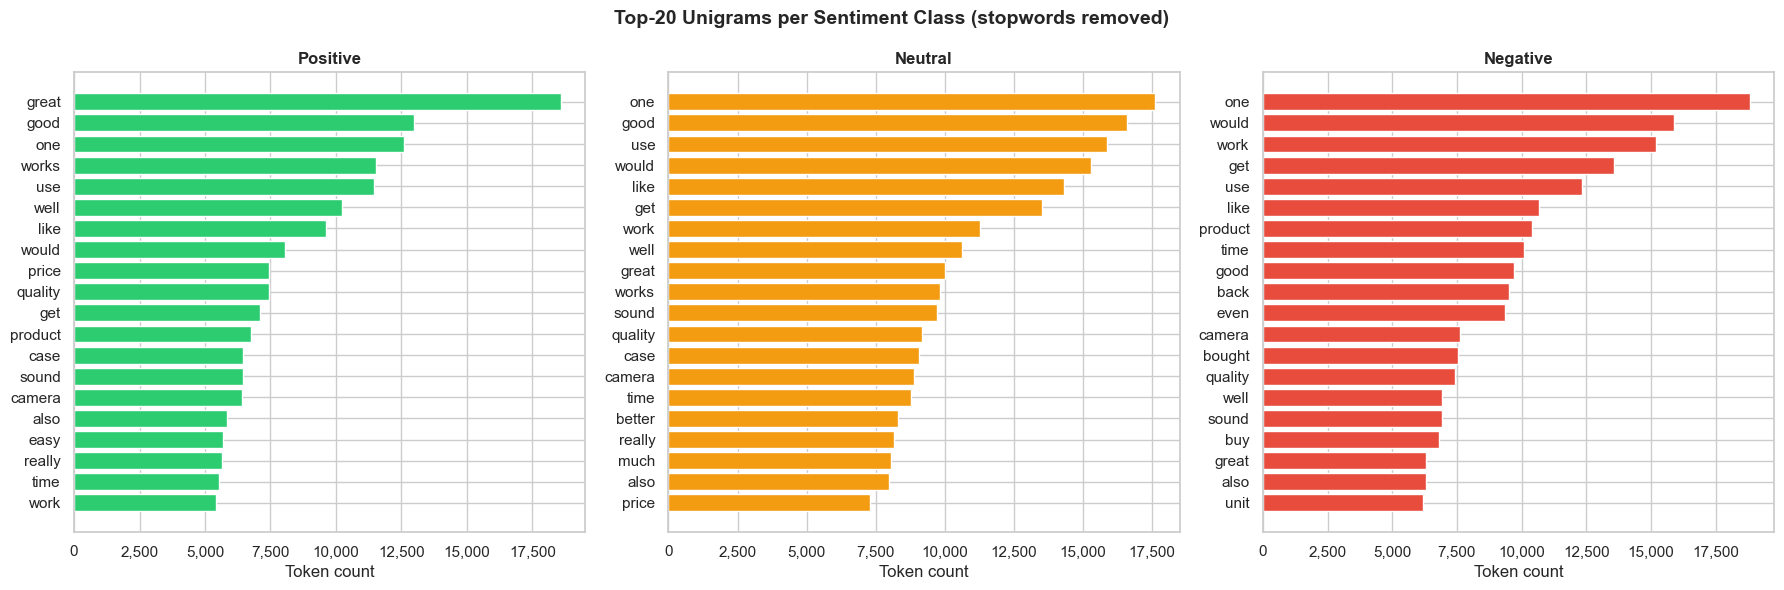


Computing TF-IDF per class …


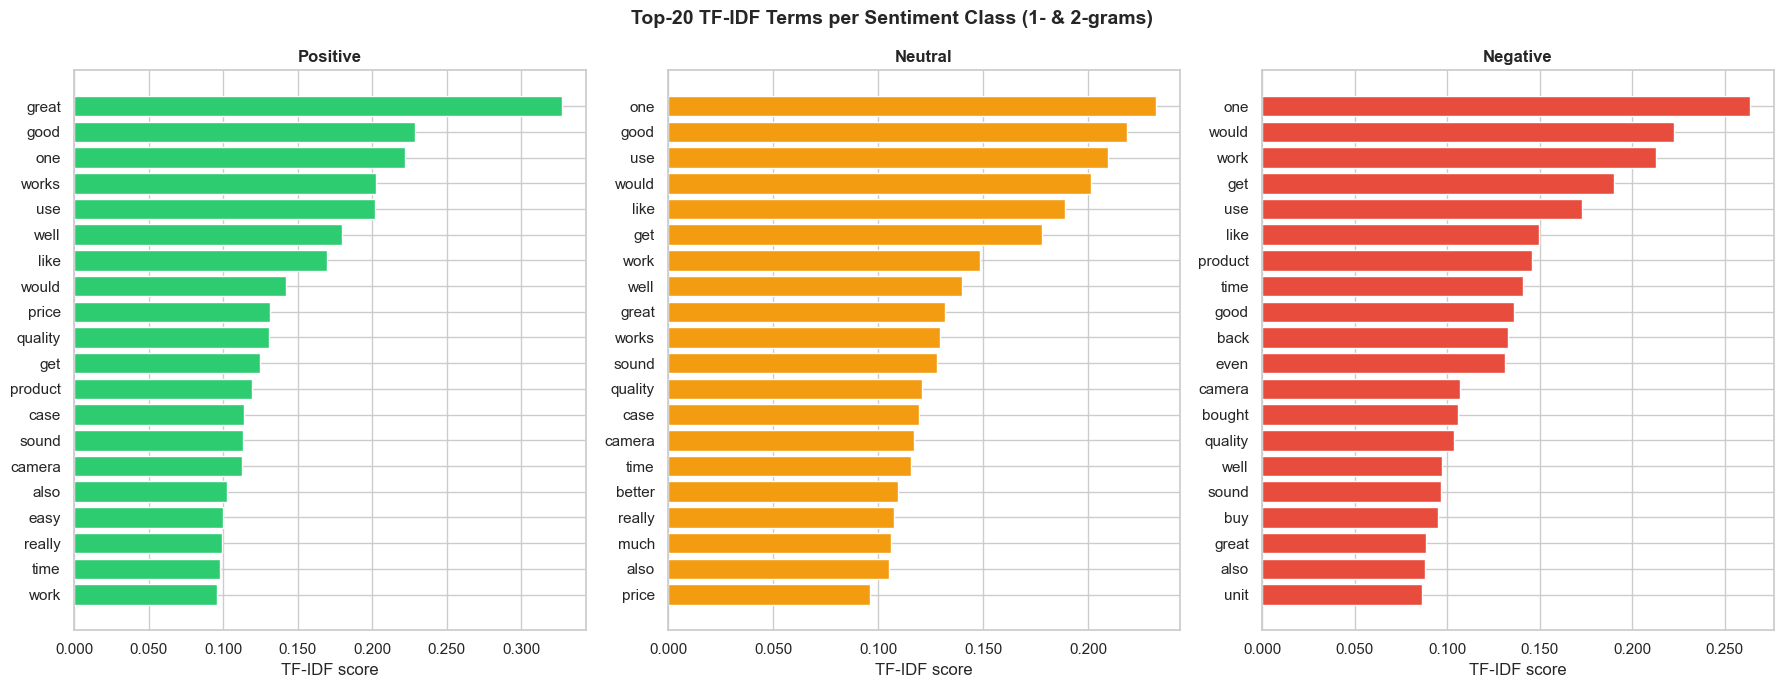


Extracting negative review bigrams …


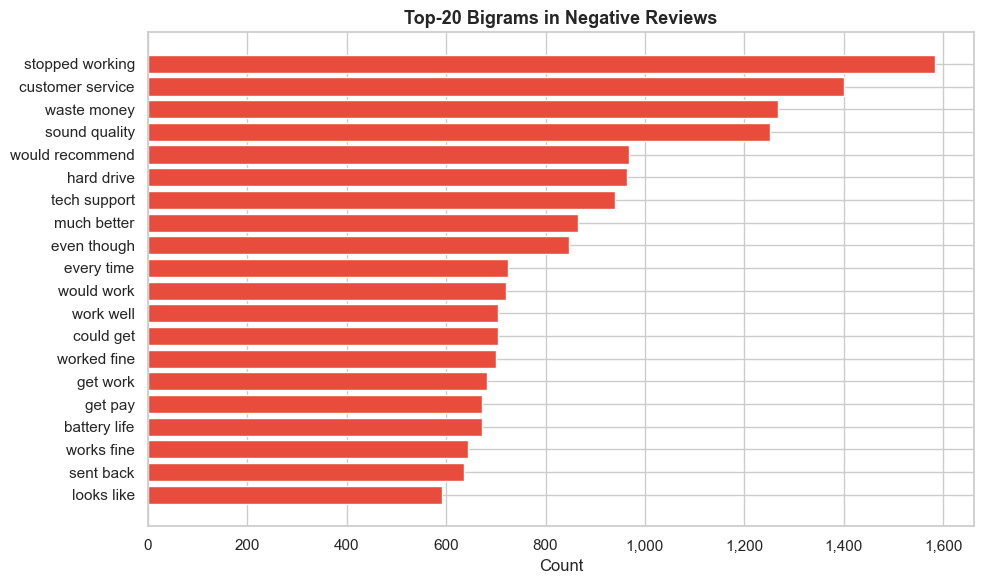


── Vocabulary Sample Summary ───────────────────────────────────────────────────────
  positive  : 50,000 reviews in sample  |  text column: clean_text_nostop
  neutral   : 50,000 reviews in sample  |  text column: clean_text_nostop
  negative  : 50,000 reviews in sample  |  text column: clean_text_nostop


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

SAMPLE_PER_CLASS = 50_000  # 50 k per class → 150 k total

# ── Balanced sample ────────────────────────────────────────────────────────────────
print("Sampling data for vocabulary analysis …")
parts = []
for label in ["positive", "neutral", "negative"]:
    sub = df_nlp[df_nlp["sentiment_label"] == label]
    n   = min(SAMPLE_PER_CLASS, len(sub))
    parts.append(sub.sample(n, random_state=42))
df_vocab = pd.concat(parts).reset_index(drop=True)

classes    = ["positive", "neutral", "negative"]
palette    = {"positive": "#2ecc71", "neutral": "#f39c12", "negative": "#e74c3c"}
text_col   = "clean_text_nostop" if "clean_text_nostop" in df_nlp.columns else "clean_text"
class_text = {c: " ".join(df_vocab[df_vocab["sentiment_label"] == c][text_col].fillna(""))
              for c in classes}

# ── 1. Top-20 unigrams per class ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top-20 Unigrams per Sentiment Class (stopwords removed)",
             fontsize=14, fontweight="bold")

for ax, label in zip(axes, classes):
    vec    = CountVectorizer(max_features=5000, ngram_range=(1, 1))
    X      = vec.fit_transform([class_text[label]])
    counts = X.toarray().flatten()
    words  = vec.get_feature_names_out()
    top20  = np.argsort(counts)[-20:][::-1]
    ax.barh(words[top20][::-1], counts[top20][::-1],
            color=palette[label], edgecolor="white")
    ax.set_title(label.capitalize(), fontweight="bold")
    ax.set_xlabel("Token count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

# ── 2. TF-IDF distinctive terms (1+2 grams) ────────────────────────────────────────
print("\nComputing TF-IDF per class …")
corpus        = [class_text[c] for c in classes]
tfidf         = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
tfidf_m       = tfidf.fit_transform(corpus)
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Top-20 TF-IDF Terms per Sentiment Class (1- & 2-grams)",
             fontsize=14, fontweight="bold")

for i, (ax, label) in enumerate(zip(axes, classes)):
    scores = tfidf_m[i].toarray().flatten()
    top20  = np.argsort(scores)[-20:][::-1]
    ax.barh(feature_names[top20][::-1], scores[top20][::-1],
            color=palette[label], edgecolor="white")
    ax.set_title(label.capitalize(), fontweight="bold")
    ax.set_xlabel("TF-IDF score")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.3f}"))

plt.tight_layout()
plt.show()

# ── 3. Top-20 bigrams in negative reviews ──────────────────────────────────────────
print("\nExtracting negative review bigrams …")
neg_text     = df_vocab[df_vocab["sentiment_label"] == "negative"][text_col].fillna("")
vec_bi       = CountVectorizer(ngram_range=(2, 2), max_features=20)
X_bi         = vec_bi.fit_transform(neg_text)
bigram_counts = X_bi.sum(axis=0).A1
bigrams       = vec_bi.get_feature_names_out()
order_bi      = np.argsort(bigram_counts)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(bigrams[order_bi][::-1], bigram_counts[order_bi][::-1],
        color="#e74c3c", edgecolor="white")
ax.set_title("Top-20 Bigrams in Negative Reviews", fontsize=13, fontweight="bold")
ax.set_xlabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("\n── Vocabulary Sample Summary ───────────────────────────────────────────────────────")
for label in classes:
    n = (df_vocab["sentiment_label"] == label).sum()
    print(f"  {label:10s}: {n:>6,} reviews in sample  |  text column: {text_col}")


## Step 16: Class Imbalance — Diagnosis & Strategy

Visualise the sentiment class distribution and evaluate three mitigation strategies:

| Strategy | Pros | Cons |
|---|---|---|
| `class_weight='balanced'` | No data loss; fast | May under-weight majority |
| Random undersampling | Balanced classes | Loses ~80 % of positive reviews |
| Binary classification (pos vs neg) | Removes ambiguous neutral | Drops neutral signal |

**Recommended default:** `class_weight='balanced'` — preserves all data and integrates with sklearn.

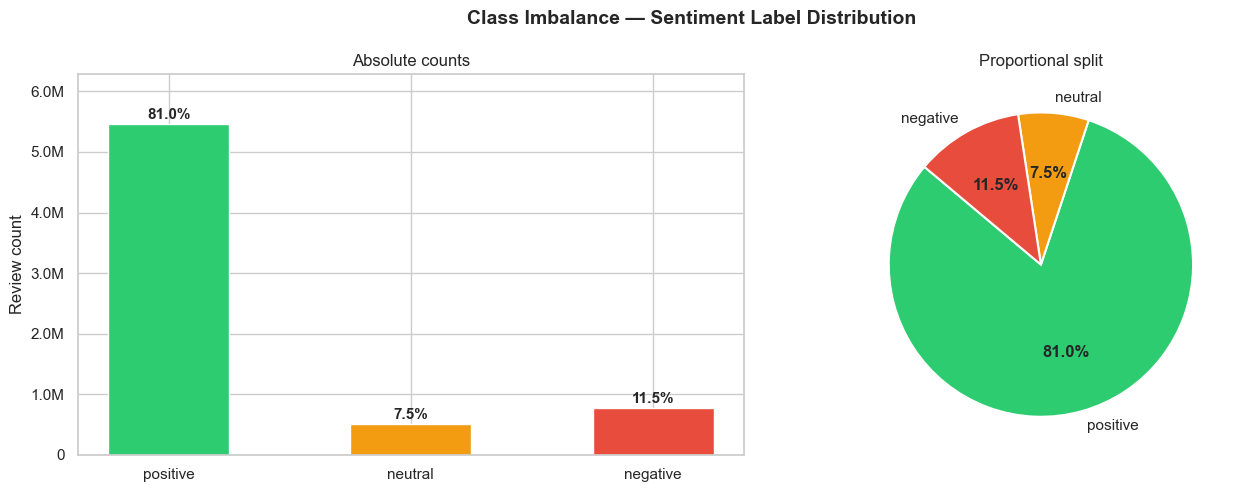


── sklearn compute_class_weight('balanced') ────────────────────────────────────
  positive  : count=5,460,975  weight=0.4114
  neutral   : count=  504,781  weight=4.4505
  negative  : count=  773,834  weight=2.9031

── Strategy Comparison ─────────────────────────────────────────────────────────────

  A) class_weight='balanced'  → pass cw_dict to sklearn estimators
     e.g. LogisticRegression(class_weight={'positive': np.float64(0.4113789204308754), 'neutral': np.float64(4.450504278092876), 'negative': np.float64(2.903116172202307)})

  B) Random undersampling to 504,781 per class → balanced dataset: 1,514,343 rows
     Data retained: 22.5% of original

  C) Binary (pos vs neg) → 6,234,809 reviews
     positive: 5,460,975  negative: 773,834  ratio: 7.1:1

── Recommendation ─────────────────────────────────────────────────────────────
  Primary strategy: class_weight='balanced' — no data loss, sklearn-native.
  Evaluate with stratified k-fold CV and macro-averaged F1 score.

  class

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ── 1. Class distribution ────────────────────────────────────────────────────────
label_counts = df_nlp["sentiment_label"].value_counts()
label_pcts   = 100 * label_counts / len(df_nlp)
palette      = {"positive": "#2ecc71", "neutral": "#f39c12", "negative": "#e74c3c"}
order        = ["positive", "neutral", "negative"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Imbalance — Sentiment Label Distribution", fontsize=14, fontweight="bold")

ax = axes[0]
bars = ax.bar(order, [label_counts[l] for l in order],
              color=[palette[l] for l in order], edgecolor="white", width=0.5)
for bar, pct in zip(bars, [label_pcts[l] for l in order]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30_000,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Review count")
ax.set_title("Absolute counts")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x/1e6):.1f}M" if x >= 1e6 else f"{int(x):,}"))
ax.set_ylim(0, label_counts.max() * 1.15)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    [label_counts[l] for l in order],
    labels=order,
    colors=[palette[l] for l in order],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for at in autotexts:
    at.set_fontweight("bold")
ax2.set_title("Proportional split")
plt.tight_layout()
plt.show()

# ── 2. sklearn class weights ──────────────────────────────────────────────────
y           = df_nlp["sentiment_label"].values
classes_arr = np.array(order)
weights     = compute_class_weight("balanced", classes=classes_arr, y=y)
cw_dict     = dict(zip(order, weights))

print("\n── sklearn compute_class_weight('balanced') ────────────────────────────────────")
for label, w in cw_dict.items():
    n = label_counts[label]
    print(f"  {label:10s}: count={n:>9,}  weight={w:.4f}")

# ── 3. Strategy comparison ───────────────────────────────────────────────────────────
print("\n── Strategy Comparison ─────────────────────────────────────────────────────────────")

# Strategy A
print("\n  A) class_weight='balanced'  → pass cw_dict to sklearn estimators")
print(f"     e.g. LogisticRegression(class_weight={cw_dict})")

# Strategy B: random undersampling
min_n   = label_counts.min()
parts_b = [df_nlp[df_nlp["sentiment_label"] == l].sample(min_n, random_state=42) for l in order]
df_balanced = pd.concat(parts_b).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\n  B) Random undersampling to {min_n:,} per class → balanced dataset: {len(df_balanced):,} rows")
print(f"     Data retained: {100*len(df_balanced)/len(df_nlp):.1f}% of original")

# Strategy C: binary
df_binary  = df_nlp[df_nlp["sentiment_label"].isin(["positive", "negative"])].copy()
bin_counts = df_binary["sentiment_label"].value_counts()
print(f"\n  C) Binary (pos vs neg) → {len(df_binary):,} reviews")
print(f"     positive: {bin_counts['positive']:,}  "
      f"negative: {bin_counts['negative']:,}  "
      f"ratio: {bin_counts['positive']/bin_counts['negative']:.1f}:1")

print("\n── Recommendation ─────────────────────────────────────────────────────────────")
print("  Primary strategy: class_weight='balanced' — no data loss, sklearn-native.")
print("  Evaluate with stratified k-fold CV and macro-averaged F1 score.")
print(f"\n  class_weight dict: {cw_dict}")


## Step 17: Feature Correlation & Redundancy Removal

Compute a Pearson correlation matrix across all numeric features on a 300 k sample:

- **Heatmap** (lower triangle) to spot multicollinear pairs (|r| ≥ 0.85)
- **Target correlation bar chart** — which features correlate most with `overall` rating
- **Auto-drop** redundant columns to keep the feature set lean before modelling

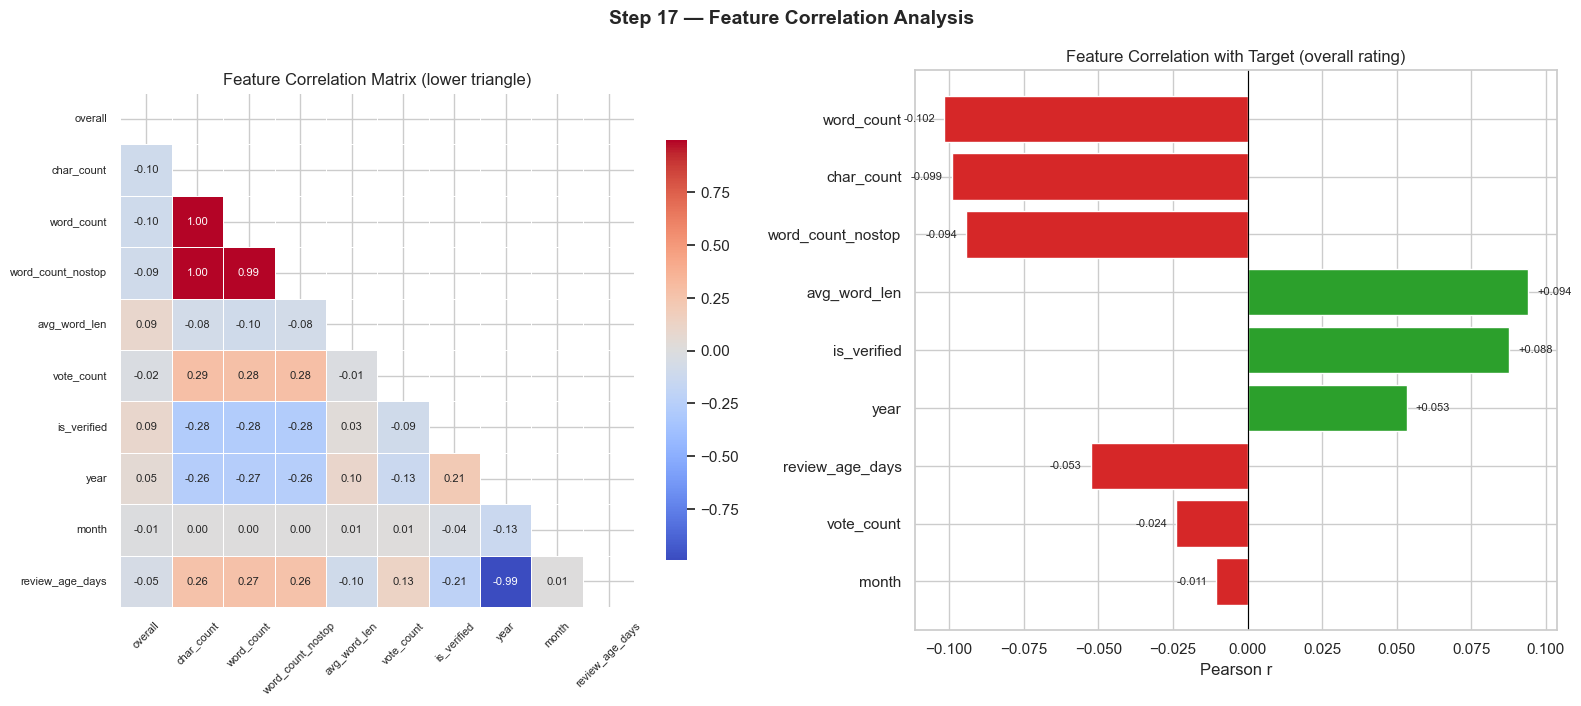

=== Highly Correlated Feature Pairs (|r| ≥ 0.85) ===
  char_count             ↔  word_count              r = +0.996
  char_count             ↔  word_count_nostop       r = +0.996
  word_count             ↔  word_count_nostop       r = +0.995
  year                   ↔  review_age_days         r = -0.992

=== Correlation with Target (ranked) ===
  word_count                 r = -0.1017  ← consider dropping (redundant)
  char_count                 r = -0.0991  ← consider dropping (redundant)
  word_count_nostop          r = -0.0942  ← consider dropping (redundant)
  avg_word_len               r = +0.0940
  is_verified                r = +0.0878
  year                       r = +0.0534  ← consider dropping (redundant)
  review_age_days            r = -0.0526  ← consider dropping (redundant)
  vote_count                 r = -0.0238
  month                      r = -0.0106

=== Recommendation ===
  Drop (redundant) : ['char_count', 'word_count']
  Keep for modelling: ['word_count_nostop', '

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

# Numeric features available after Step 14
numeric_cols = [
    "overall", "char_count", "word_count", "word_count_nostop",
    "avg_word_len", "vote_count", "is_verified",
    "year", "month", "review_age_days"
]
# Keep only columns that actually exist (word_count_nostop needs Step 14 to have run)
numeric_cols = [c for c in numeric_cols if c in df_nlp.columns]

# Compute on a 300k sample — correlation is stable at this scale
CORR_N = 300_000
df_corr = df_nlp[numeric_cols].dropna().sample(min(CORR_N, len(df_nlp)), random_state=42)
corr = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Step 17 — Feature Correlation Analysis", fontsize=14, fontweight="bold")

# Full lower-triangle heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, ax=axes[0], square=True,
    annot_kws={"size": 8}, linewidths=0.5,
    cbar_kws={"shrink": 0.75}
)
axes[0].set_title("Feature Correlation Matrix (lower triangle)")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

# Correlation with target (overall rating)
target_corr = corr["overall"].drop("overall").sort_values(key=abs, ascending=True)
bar_cols = ["#d62728" if v < 0 else "#2ca02c" for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=bar_cols, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with Target (overall rating)")
axes[1].set_xlabel("Pearson r")
for i, v in enumerate(target_corr.values):
    offset = 0.003 if v >= 0 else -0.003
    ha = "left" if v >= 0 else "right"
    axes[1].text(v + offset, i, f"{v:+.3f}", va="center", ha=ha, fontsize=8)

plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("=== Highly Correlated Feature Pairs (|r| ≥ 0.85) ===")
high_corr_pairs = []
cols = list(corr.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.85:
            high_corr_pairs.append((cols[i], cols[j], r))
            print(f"  {cols[i]:<22} ↔  {cols[j]:<22}  r = {r:+.3f}")

if not high_corr_pairs:
    print("  None found — all features are sufficiently independent.")

# Feature selection recommendation
print("\n=== Correlation with Target (ranked) ===")
for feat, r in target_corr.sort_values(key=abs, ascending=False).items():
    redundant = any(feat in (a, b) and abs(rv) >= 0.92 for a, b, rv in high_corr_pairs)
    flag = "  ← consider dropping (redundant)" if redundant else ""
    print(f"  {feat:<25}  r = {r:+.4f}{flag}")

print("\n=== Recommendation ===")
# char_count vs word_count are almost certainly r > 0.95
# word_count_nostop vs word_count also very high
# Keep word_count_nostop as the single token-count feature
drop_rec = []
if any("char_count" in (a, b) for a, b, r in high_corr_pairs if abs(r) >= 0.92):
    drop_rec.append("char_count")
if any({"word_count", "word_count_nostop"} == {a, b} for a, b, r in high_corr_pairs if abs(r) >= 0.92):
    drop_rec.append("word_count")  # keep word_count_nostop

keep = [c for c in numeric_cols if c not in drop_rec and c != "overall"]
print(f"  Drop (redundant) : {drop_rec}")
print(f"  Keep for modelling: {keep}")

# Apply drop to df_nlp
if drop_rec:
    existing_drops = [c for c in drop_rec if c in df_nlp.columns]
    df_nlp.drop(columns=existing_drops, inplace=True)
    print(f"\n✓ Dropped {existing_drops} from df_nlp.")
    print(f"  df_nlp shape now: {df_nlp.shape}")

## Step 17b: Classical Baseline Models — Naive Bayes & Logistic Regression

Before using DistilBERT (a large transformer), we establish classical baselines using
**TF-IDF features** and two well-known classifiers taught in this course:

- **Complement Naive Bayes** (best Naive Bayes variant for imbalanced text data)
- **Logistic Regression** with SMOTE oversampling

Pipeline:
1. Load 300K sample and draw a **stratified 50K subset** (feasible on a laptop)
2. Vectorise with **TF-IDF** (max 15,000 features, unigrams + bigrams)
3. Reduce to 100 dense dimensions via **TruncatedSVD** (required for SMOTE)
4. Apply **SMOTE** to balance the three sentiment classes
5. Train and evaluate both classifiers — results are compared against DistilBERT

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_24187/2006457044.py:11: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_300k = pd.read_csv(SAMPLE_PK)
/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_24187/2006457044.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


Full 300K shape: (300000, 25)
50K subset shape : (49999, 25)

Class distribution (50K subset):
sentiment_label
positive    40245
negative     5937
neutral      3817


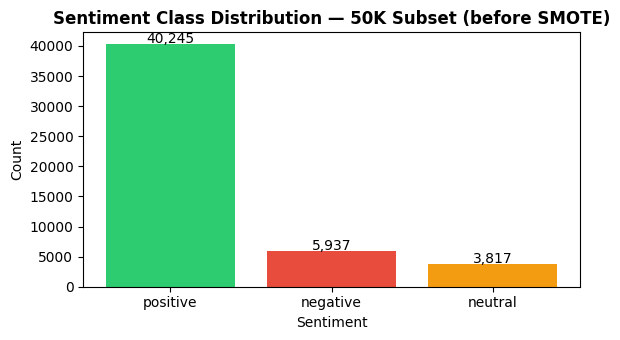


Chart saved → reports/class_distribution_before_smote.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE      = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
SAMPLE_PK = f"{BASE}/data/processed/sample_300k.csv"

# Load 300K and draw a stratified 50K subset for feasibility
df_300k = pd.read_csv(SAMPLE_PK)
print(f"Full 300K shape: {df_300k.shape}")

df_50k = (df_300k
          .dropna(subset=["clean_text", "sentiment_label"])
          .groupby("sentiment_label", group_keys=False)
          .apply(lambda g: g.sample(
              min(len(g), int(50_000 * len(g) / len(df_300k))),
              random_state=42))
          .sample(frac=1, random_state=42)
          .reset_index(drop=True))

print(f"50K subset shape : {df_50k.shape}")
print("\nClass distribution (50K subset):")
dist = df_50k["sentiment_label"].value_counts()
print(dist.to_string())

# Bar chart of class distribution
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = {"positive": "#2ecc71", "neutral": "#f39c12", "negative": "#e74c3c"}
ax.bar(dist.index, dist.values,
       color=[colors.get(l, "steelblue") for l in dist.index])
ax.set_title("Sentiment Class Distribution — 50K Subset (before SMOTE)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Sentiment"); ax.set_ylabel("Count")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{BASE}/reports/class_distribution_before_smote.png", dpi=150)
plt.show()
print("\nChart saved → reports/class_distribution_before_smote.png")

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

LABEL2ID = {"positive": 2, "neutral": 1, "negative": 0}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

X_raw = df_50k["clean_text"].astype(str).tolist()
y_raw = df_50k["sentiment_label"].map(LABEL2ID).values

# 80/20 stratified split BEFORE SMOTE (never SMOTE the test set)
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42)

print(f"Train: {len(X_tr_raw):,} | Test: {len(X_te_raw):,}")

# TF-IDF — unigrams + bigrams, max 15K features
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=15_000,
                         sublinear_tf=True, min_df=3)
X_tr_tfidf = tfidf.fit_transform(X_tr_raw)
X_te_tfidf = tfidf.transform(X_te_raw)
print(f"TF-IDF matrix: {X_tr_tfidf.shape}")

# TruncatedSVD: reduce to 100 dims so SMOTE can interpolate
svd = TruncatedSVD(n_components=100, random_state=42)
X_tr_svd = svd.fit_transform(X_tr_tfidf)
X_te_svd  = svd.transform(X_te_tfidf)
print(f"After SVD    : {X_tr_svd.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.1%}")

# SMOTE — balance to equal class sizes
print("\nClass counts BEFORE SMOTE:", dict(zip(*np.unique(y_tr, return_counts=True))))
smote = SMOTE(random_state=42, k_neighbors=5)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_svd, y_tr)
print("Class counts AFTER  SMOTE:", dict(zip(*np.unique(y_tr_sm, return_counts=True))))
print(f"Training set size after SMOTE: {len(y_tr_sm):,}")

Train: 39,999 | Test: 10,000
TF-IDF matrix: (39999, 15000)
After SVD    : (39999, 100)
Variance explained: 19.8%

Class counts BEFORE SMOTE: {np.int64(0): np.int64(4749), np.int64(1): np.int64(3054), np.int64(2): np.int64(32196)}
Class counts AFTER  SMOTE: {np.int64(0): np.int64(32196), np.int64(1): np.int64(32196), np.int64(2): np.int64(32196)}
Training set size after SMOTE: 96,588


  COMPLEMENT NAIVE BAYES — Results
  Accuracy  : 0.6782
  Macro F1  : 0.5169

              precision    recall  f1-score   support

    negative       0.40      0.65      0.50      1188
     neutral       0.17      0.45      0.25       763
    positive       0.93      0.70      0.80      8049

    accuracy                           0.68     10000
   macro avg       0.50      0.60      0.52     10000
weighted avg       0.81      0.68      0.72     10000



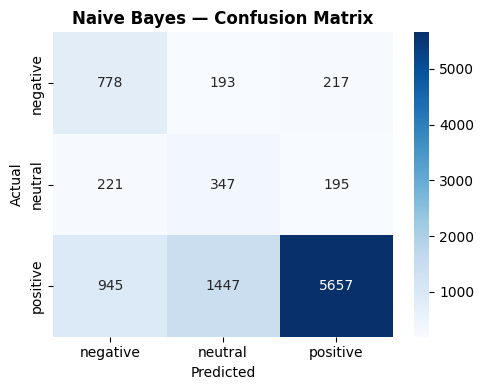

Saved → reports/naive_bayes_confusion_matrix.png


In [3]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ComplementNB requires non-negative inputs — shift SVD output
X_tr_nb = X_tr_sm - X_tr_sm.min()
X_te_nb = X_te_svd - X_te_svd.min()

nb = ComplementNB(alpha=0.5)
nb.fit(X_tr_nb, y_tr_sm)
y_pred_nb = nb.predict(X_te_nb)

acc_nb    = accuracy_score(y_te, y_pred_nb)
macro_f1_nb = f1_score(y_te, y_pred_nb, average="macro")

print("=" * 50)
print("  COMPLEMENT NAIVE BAYES — Results")
print("=" * 50)
print(f"  Accuracy  : {acc_nb:.4f}")
print(f"  Macro F1  : {macro_f1_nb:.4f}")
print()
print(classification_report(y_te, y_pred_nb,
      target_names=[ID2LABEL[i] for i in sorted(ID2LABEL)]))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred_nb)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)],
            yticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)], ax=ax)
ax.set_title("Naive Bayes — Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{BASE}/reports/naive_bayes_confusion_matrix.png", dpi=150)
plt.show()
print("Saved → reports/naive_bayes_confusion_matrix.png")

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  LOGISTIC REGRESSION — Results
  Accuracy  : 0.7137
  Macro F1  : 0.5537

              precision    recall  f1-score   support

    negative       0.45      0.66      0.54      1188
     neutral       0.20      0.53      0.29       763
    positive       0.95      0.74      0.83      8049

    accuracy                           0.71     10000
   macro avg       0.53      0.64      0.55     10000
weighted avg       0.83      0.71      0.76     10000



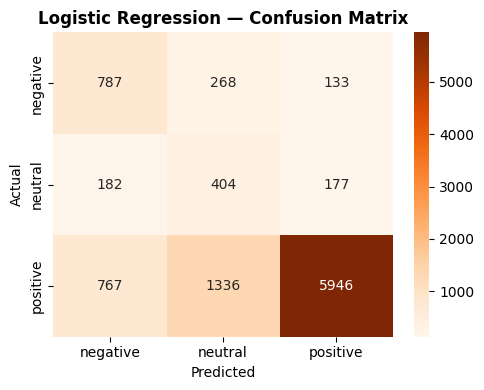

Saved → reports/logistic_regression_confusion_matrix.png


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver="lbfgs", n_jobs=-1)
lr.fit(X_tr_sm, y_tr_sm)
y_pred_lr = lr.predict(X_te_svd)

acc_lr     = accuracy_score(y_te, y_pred_lr)
macro_f1_lr = f1_score(y_te, y_pred_lr, average="macro")

print("=" * 50)
print("  LOGISTIC REGRESSION — Results")
print("=" * 50)
print(f"  Accuracy  : {acc_lr:.4f}")
print(f"  Macro F1  : {macro_f1_lr:.4f}")
print()
print(classification_report(y_te, y_pred_lr,
      target_names=[ID2LABEL[i] for i in sorted(ID2LABEL)]))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)],
            yticklabels=[ID2LABEL[i] for i in sorted(ID2LABEL)], ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{BASE}/reports/logistic_regression_confusion_matrix.png", dpi=150)
plt.show()
print("Saved → reports/logistic_regression_confusion_matrix.png")

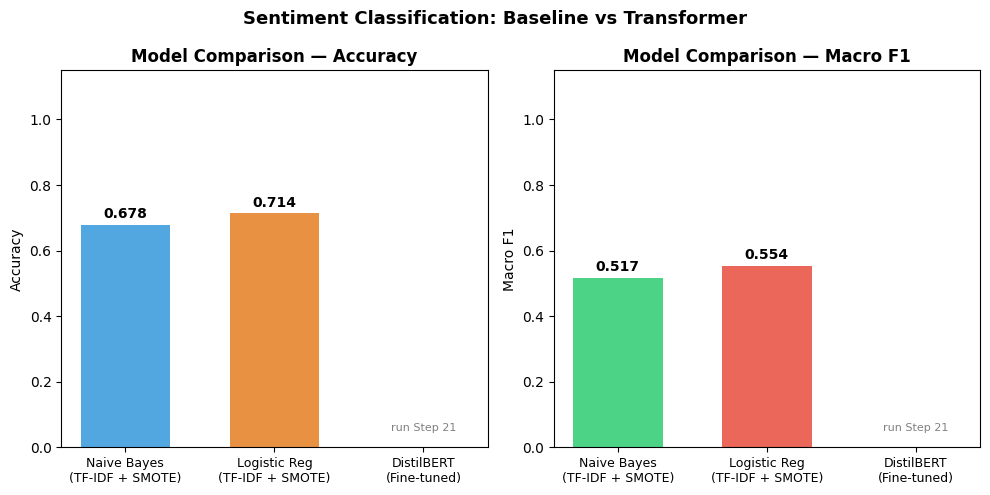


Summary:
  Naive Bayes   — Accuracy: 0.678 | Macro F1: 0.517
  Logistic Reg  — Accuracy: 0.714 | Macro F1: 0.554
  DistilBERT    — run Step 21 to get scores

Saved → reports/model_comparison.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import json as _json
from pathlib import Path

# Safely read baseline scores from prior cells
_g = globals()
acc_nb      = _g.get("acc_nb")
macro_f1_nb = _g.get("macro_f1_nb")
acc_lr      = _g.get("acc_lr")
macro_f1_lr = _g.get("macro_f1_lr")

if acc_nb is None or acc_lr is None:
    print("Run cells B→C→D→E first (Naive Bayes and Logistic Regression cells), then re-run this cell.")
else:
    BASE = "/Users/shashikamihiranga/Desktop/NPL Assement 03"

    # Auto-load DistilBERT metrics if Step 21 has been run
    _db_path = Path(f"{BASE}/reports/distilbert_metrics.json")
    if _db_path.exists():
        with open(_db_path) as _fh:
            _db = _json.load(_fh)
        distilbert_accuracy = _db["accuracy"]
        distilbert_macro_f1 = _db["macro_f1"]
        print(f"DistilBERT metrics loaded: accuracy={distilbert_accuracy:.3f}  macro_F1={distilbert_macro_f1:.3f}")
    else:
        distilbert_accuracy = None
        distilbert_macro_f1 = None
        print("DistilBERT metrics not found — run Step 21 first, then re-run this cell.")

    results = {
        "Naive Bayes\n(TF-IDF + SMOTE)" : {"Accuracy": acc_nb,            "Macro F1": macro_f1_nb},
        "Logistic Reg\n(TF-IDF + SMOTE)": {"Accuracy": acc_lr,            "Macro F1": macro_f1_lr},
        "DistilBERT\n(Fine-tuned)"       : {"Accuracy": distilbert_accuracy,"Macro F1": distilbert_macro_f1},
    }

    metrics = ["Accuracy", "Macro F1"]
    x       = np.arange(len(results))
    colors  = [["#3498db", "#2ecc71"], ["#e67e22", "#e74c3c"], ["#9b59b6", "#1abc9c"]]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for mi, metric in enumerate(metrics):
        ax = axes[mi]
        vals = [v[metric] for v in results.values()]
        bars = ax.bar(x, [v if v else 0 for v in vals],
                      color=[c[mi % 2] for c in colors], width=0.6, alpha=0.85)
        ax.set_title(f"Model Comparison — {metric}", fontweight="bold", fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(list(results.keys()), fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric)
        for bar, val in zip(bars, vals):
            if val:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
            else:
                ax.text(bar.get_x() + bar.get_width()/2, 0.05,
                        "run Step 21", ha="center", fontsize=8, color="gray")

    plt.suptitle("Sentiment Classification: Baseline vs Transformer",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{BASE}/reports/model_comparison.png", dpi=150)
    plt.show()

    print(f"\nSummary:")
    print(f"  Naive Bayes  — Accuracy: {acc_nb:.3f} | Macro F1: {macro_f1_nb:.3f}")
    print(f"  Logistic Reg — Accuracy: {acc_lr:.3f} | Macro F1: {macro_f1_lr:.3f}")
    if distilbert_accuracy:
        print(f"  DistilBERT   — Accuracy: {distilbert_accuracy:.3f} | Macro F1: {distilbert_macro_f1:.3f}")
    print("Saved → reports/model_comparison.png")


## Step 18: Load NLP-Ready Data & Run Augmentation Pipeline

### Why we sample minority classes instead of augmenting all of them
The full dataset has ~773 k negative and ~505 k neutral rows.
Each sample needs 2 translation API calls + BERT inference (~1–3 s each).
Augmenting every minority row would take **300 + hours**.
The practical strategy:
1. Draw a fixed sample from minority classes (default `AUGMENT_N = 500` per class)
2. Augment those to get 2× synthetic copies per sample
3. Combine augmented rows with the **full** original dataset

Increase `AUGMENT_N` when you have more time / GPU resources.

In [27]:
import sys, os
import pandas as pd

BASE    = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
NLP_CSV = os.path.join(BASE, "data", "processed", "electronics_nlp_ready.csv")

if os.path.join(BASE, "src") not in sys.path:
    sys.path.insert(0, os.path.join(BASE, "src"))

print("Loading electronics_nlp_ready.csv …")
df_nlp = pd.read_csv(NLP_CSV, low_memory=False)
print(f"Loaded: {df_nlp.shape[0]:,} rows  {df_nlp.shape[1]} columns")

label_counts = df_nlp["sentiment_label"].value_counts()
print("\nClass distribution:")
for label, n in label_counts.items():
    print(f"  {label:10s}: {n:>9,}  ({100*n/len(df_nlp):.1f}%)")


Loading electronics_nlp_ready.csv …
Loaded: 6,739,590 rows  25 columns

Class distribution:
  positive  : 5,460,975  (81.0%)
  negative  :   773,834  (11.5%)
  neutral   :   504,781  (7.5%)


In [8]:
import os, sys, subprocess, time
import torch
import pandas as pd

# ── Make src/ importable regardless of whether the load cell ran first ───────
BASE = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
_src = os.path.join(BASE, "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

import importlib, augmentation_pipeline
importlib.reload(augmentation_pipeline)
from augmentation_pipeline import augment_dataframe

# ── Guard: df_nlp must exist (run the load cell above first) ─────────────────
if "df_nlp" not in dir():
    raise RuntimeError(
        "df_nlp is not defined. Run the 'Load NLP-Ready Data' cell above first."
    )
# ── System: prevent sleep and disable low-power mode during long runs ─────────
_caffeinate = subprocess.Popen(["caffeinate", "-i"])
os.system("sudo pmset -a lowpowermode 0 2>/dev/null")

# ── CPU threading: all 10 performance cores + HF tokenizer parallelism ───────
os.environ["TOKENIZERS_PARALLELISM"] = "true"
torch.set_num_threads(10)

# ── Device: MPS (40-core GPU) > CUDA > CPU ────────────────────────────────────
if torch.backends.mps.is_available():
    _DEVICE = "mps"
elif torch.cuda.is_available():
    _DEVICE = "cuda"
else:
    _DEVICE = "cpu"
print(f"Device: {_DEVICE}")

# ── Parameters ────────────────────────────────────────────────────────────────
AUGMENT_N             = 500    # rows sampled per minority class
AUGMENTATIONS_PER_ROW = 2      # synthetic copies per sample
SIM_THRESHOLD         = 0.75   # cosine similarity cutoff
AUG_P                 = 0.175  # fraction of words replaced by BERT (0.15–0.20)
DELAY_RANGE           = (0.5, 1.5)
RANDOM_SEED           = 42
N_CHUNKS              = 10     # chunks for progress reporting
BATCH_SIZE            = 256    # BERT inference batch size (push to 512 if memory allows)
AUG_OUT = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/electronics_augmented.csv"

# ── Fix: detect minority classes from the FULL dataset BEFORE sampling ────────
# The old code sampled equal rows per class first, so count/max_count == 1.0
# for every class inside augment_dataframe, and 1.0 < 0.99 is always False.
# Doing the check here on df_nlp (6.7 M rows) gives the real imbalance ratios.
label_counts_full = df_nlp["sentiment_label"].value_counts()
max_count_full    = label_counts_full.max()
minority_labels   = label_counts_full[
    label_counts_full / max_count_full < 0.50
].index.tolist()

print("\nClass distribution (full dataset):")
for lbl, n in label_counts_full.items():
    ratio = n / max_count_full
    tag   = " ← minority" if lbl in minority_labels else ""
    print(f"  {lbl:10s}: {n:>9,}  ({ratio:.1%} of majority){tag}")

# ── Sample only minority-class rows ───────────────────────────────────────────
df_to_aug = pd.concat([
    df_nlp[df_nlp["sentiment_label"] == lbl].sample(
        min(AUGMENT_N, label_counts_full[lbl]),
        random_state=RANDOM_SEED,
    )
    for lbl in minority_labels
]).reset_index(drop=True)
print(f"\nRows sent to pipeline: {len(df_to_aug):,} "
      f"({AUGMENT_N} per class × {len(minority_labels)} minority classes)")

# ── Split into N_CHUNKS for per-chunk progress reporting ──────────────────────
# ProcessPoolExecutor cannot share an MPS model across processes, so we chunk
# sequentially on the main process (MPS) and use ThreadPoolExecutor for the
# I/O-bound back-translation calls inside the pipeline.
chunk_dfs = [df_to_aug.iloc[i::N_CHUNKS].copy() for i in range(N_CHUNKS)]
chunk_dfs = [c for c in chunk_dfs if len(c) > 0]
print(f"Split into {len(chunk_dfs)} chunks (~{len(chunk_dfs[0])} rows each)")

# ── Process chunks with live progress ────────────────────────────────────────
all_synthetic = []
t_start = time.perf_counter()

for i, chunk in enumerate(chunk_dfs, 1):
    t_chunk = time.perf_counter()
    print(f"\n[{i}/{len(chunk_dfs)}] chunk={len(chunk)} rows …", flush=True)

    # imbalance_ratio=1.1 → any class with count/max < 1.1 is minority.
    # Since count/max is always ≤ 1.0 < 1.1, every pre-sampled class triggers.
    df_aug = augment_dataframe(chunk, text_col="clean_text", label_col="sentiment_label", imbalance_ratio=1.1, augmentations_per_sample=AUGMENTATIONS_PER_ROW, sim_threshold=SIM_THRESHOLD, aug_p=AUG_P, delay_range=DELAY_RANGE, output_path=None, random_state=RANDOM_SEED, batch_size=BATCH_SIZE,)

    synthetic = df_aug[df_aug["is_augmented"]].copy()
    all_synthetic.append(synthetic)
    elapsed = time.perf_counter() - t_chunk
    rate    = len(chunk) / elapsed if elapsed > 0 else 0
    print(f"  → {len(synthetic):,} synthetic rows accepted  "
          f"|  {elapsed:.0f}s  |  {rate:.2f} rows/s", flush=True)

# ── Combine synthetic rows with full original dataset ─────────────────────────
df_synthetic = pd.concat(all_synthetic, ignore_index=True)
df_nlp["is_augmented"] = False
df_final = pd.concat([df_nlp, df_synthetic], ignore_index=True)

total_s = time.perf_counter() - t_start
print(f"\nTotal time: {total_s/60:.1f} min")
print(f"Synthetic rows added: {len(df_synthetic):,}")
print(f"Final dataset: {len(df_final):,} rows")

print("\nClass distribution (after augmentation):")
for lbl, n in df_final["sentiment_label"].value_counts().items():
    print(f"  {lbl:10s}: {n:>9,}  ({100*n/len(df_final):.1f}%)")

df_final.to_csv(AUG_OUT, index=False)
print(f"\nSaved → {AUG_OUT}")

# ── Stop caffeinate ───────────────────────────────────────────────────────────
_caffeinate.terminate()

# ── Run summary ───────────────────────────────────────────────────────────────
throughput = len(df_to_aug) / total_s if total_s > 0 else 0
print(f"""
{'='*52}
  RUN SUMMARY
{'='*52}
  Device          : {_DEVICE}
  CPU threads     : 10 (performance cores)
  BERT batch size : {BATCH_SIZE}
  Chunks          : {len(chunk_dfs)}
  Rows processed  : {len(df_to_aug):,}
  Synthetic added : {len(df_synthetic):,}
  Total time      : {total_s/60:.1f} min
  Throughput      : {throughput:.2f} rows/s
{'='*52}
""")


Device: mps

Class distribution (full dataset):
  positive  : 5,460,975  (100.0% of majority)
  negative  :   773,834  (14.2% of majority) ← minority
  neutral   :   504,781  (9.2% of majority) ← minority

Rows sent to pipeline: 1,000 (500 per class × 2 minority classes)
Split into 10 chunks (~100 rows each)

[1/10] chunk=100 rows …


15:19:39  INFO      Original class counts:
sentiment_label
negative    50
neutral     50
15:19:39  INFO      Minority classes (count/max < 1.10): ['negative', 'neutral']
15:19:39  INFO      Loading BERT fill-mask pipeline on mps (dtype=torch.float16, batch=256) …
15:19:42  INFO      HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 2216.66it/s]
15:19:43  INFO      HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
15:19:43  INFO      HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
15:19:43  INFO      HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
1

KeyboardInterrupt: 

## Step 19: Aspect-Based Sentiment Analysis (ABSA) with DeepSeek-R1:8b

Use the locally running DeepSeek-R1:8b model (via Ollama) to extract **product aspects** and their **per-aspect sentiment** from electronics reviews.

### Aspects tracked
| Aspect | Examples |
|---|---|
| `battery_life` | *'battery dies fast'*, *'lasts 20 hours'* |
| `screen_display` | *'vivid colours'*, *'dim outdoors'* |
| `sound_audio` | *'great bass'*, *'tinny speakers'* |
| `build_quality` | *'feels cheap'*, *'solid metal body'* |
| `price_value` | *'worth every penny'*, *'overpriced'* |
| `performance` | *'fast processor'*, *'lags constantly'* |
| `connectivity` | *'bluetooth drops'*, *'wifi is stable'* |
| `camera` | *'sharp photos'*, *'blurry in low light'* |
| `software_app` | *'easy to use'*, *'buggy firmware'* |
| `design` | *'sleek look'*, *'too bulky'* |
| `delivery` | *'arrived damaged'*, *'fast shipping'* |
| `customer_service` | *'great support'*, *'no response'* |

### What this produces for your report
- Aspect frequency table and bar chart
- Aspect × sentiment heatmap
- Stacked sentiment bar per aspect
- Top positive and negative phrases per aspect
- Per-brand aspect breakdown
- Printable summary statistics block

In [14]:
import requests, json, re, time
import pandas as pd
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
MODEL          = "deepseek-r1:8b"
OLLAMA_URL     = "http://localhost:11434/api/generate"
SAMPLE_N       = 500   # per sentiment class → 1,500 total (~45 min)
CHECKPOINT     = 50    # save every N reviews
ASPECTS_CSV    = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/aspect_results.csv"

ASPECTS = [
    "battery_life", "screen_display", "sound_audio", "build_quality",
    "price_value", "performance", "connectivity", "camera",
    "software_app", "design", "delivery", "customer_service",
]

# ── Prompt ────────────────────────────────────────────────────────────────────
# temperature=0.1 keeps output deterministic; num_predict caps token length
# The prompt explicitly bans explanation so DeepSeek outputs only JSON
PROMPT = """You are an electronics review analyser. Extract product aspects and their sentiment.

Rules:
- Return ONLY a JSON array, nothing else
- Each item: {{"aspect": "<aspect>", "sentiment": "<positive|neutral|negative>", "phrase": "<exact quote max 8 words>"}}
- Only include aspects explicitly mentioned in the review
- Valid aspects: battery_life, screen_display, sound_audio, build_quality, price_value, performance, connectivity, camera, software_app, design, delivery, customer_service

Review: "{text}"

JSON:"""

# ── Ollama query ─────────────────────────────────────────────────────────────
def query_ollama(text):
    """Send review to DeepSeek-R1 and parse the JSON aspect list."""
    try:
        resp = requests.post(
            OLLAMA_URL,
            json={
                "model": MODEL,
                "prompt": PROMPT.format(text=str(text)[:400]),
                "stream": False,
                "options": {"temperature": 0.1, "num_predict": -1},
            },
            timeout=120,
        )
        raw = resp.json()["response"].strip()
        # DeepSeek-R1 prepends <think>…</think> — strip it, then grab the JSON array
        raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
        match = re.search(r"\[.*?\]", raw, re.DOTALL)
        return json.loads(match.group()) if match else []
    except Exception:
        return []

# ── Stratified sample: equal rows per sentiment class ─────────────────────────
# Equal sampling ensures the aspect analysis isn't dominated by positive reviews
parts = []
for label in ["positive", "neutral", "negative"]:
    sub = (
        df_nlp[df_nlp["sentiment_label"] == label]
        .dropna(subset=["clean_text"])
        .loc[lambda d: d["clean_text"].str.split().str.len()
             .ge(10)]                        # skip very short reviews
    )
    parts.append(sub.sample(min(SAMPLE_N, len(sub)), random_state=42))

df_sample = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Sample: {len(df_sample):,} reviews  "
      f"({df_sample['sentiment_label'].value_counts().to_dict()})")

# Resume from checkpoint if one exists
if Path(ASPECTS_CSV).exists():
    df_existing = pd.read_csv(ASPECTS_CSV)
    done_ids    = set(df_existing["review_idx"].unique())
    results     = df_existing.to_dict("records")
    print(f"Resuming from checkpoint: {len(done_ids)} reviews already done")
else:
    done_ids, results = set(), []

# ── Extraction loop ───────────────────────────────────────────────────────────
t0        = time.perf_counter()
processed = 0

for i, row in df_sample.iterrows():
    if i in done_ids:
        continue

    aspects = query_ollama(row["clean_text"])
    for asp in aspects:
        if isinstance(asp, dict) and asp.get("aspect", "") in ASPECTS:   # skip if model returned a string
            results.append({
                "review_idx"      : i,
                "sentiment_label" : row["sentiment_label"],
                "overall"         : row.get("overall", None),
                "brand"           : row.get("brand", ""),
                "category"        : row.get("category", ""),
                "aspect"          : asp.get("aspect", ""),
                "aspect_sentiment": asp.get("sentiment", ""),
                "phrase"          : asp.get("phrase", ""),
            })

    processed += 1

    if processed % CHECKPOINT == 0:
        pd.DataFrame(results).to_csv(ASPECTS_CSV, index=False)
        elapsed = time.perf_counter() - t0
        rate    = processed / elapsed
        eta_min = (len(df_sample) - processed) / rate / 60
        print(f"  [{processed}/{len(df_sample)}]  "
              f"aspects={len(results):,}  |  "
              f"{rate:.2f} reviews/s  |  ETA ~{eta_min:.0f} min",
              flush=True)

df_aspects = pd.DataFrame(results)
df_aspects.to_csv(ASPECTS_CSV, index=False)
total_min = (time.perf_counter() - t0) / 60
print(f"\n✓ Done in {total_min:.1f} min")
print(f"  {len(df_sample):,} reviews  →  {len(df_aspects):,} aspect mentions")
print(f"  Avg aspects per review: {len(df_aspects)/len(df_sample):.1f}")
print(f"  Saved → {ASPECTS_CSV}")


Sample: 1,500 reviews  ({'negative': 500, 'positive': 500, 'neutral': 500})
Resuming from checkpoint: 221 reviews already done
  [50/1500]  aspects=577  |  0.05 reviews/s  |  ETA ~464 min
  [100/1500]  aspects=682  |  0.06 reviews/s  |  ETA ~416 min
  [150/1500]  aspects=789  |  0.06 reviews/s  |  ETA ~385 min
  [200/1500]  aspects=889  |  0.06 reviews/s  |  ETA ~370 min
  [250/1500]  aspects=996  |  0.06 reviews/s  |  ETA ~350 min
  [300/1500]  aspects=1,111  |  0.06 reviews/s  |  ETA ~337 min
  [350/1500]  aspects=1,199  |  0.06 reviews/s  |  ETA ~334 min
  [400/1500]  aspects=1,309  |  0.06 reviews/s  |  ETA ~324 min
  [450/1500]  aspects=1,413  |  0.06 reviews/s  |  ETA ~307 min
  [500/1500]  aspects=1,513  |  0.06 reviews/s  |  ETA ~297 min
  [550/1500]  aspects=1,602  |  0.05 reviews/s  |  ETA ~291 min
  [600/1500]  aspects=1,694  |  0.06 reviews/s  |  ETA ~272 min
  [650/1500]  aspects=1,791  |  0.05 reviews/s  |  ETA ~258 min
  [700/1500]  aspects=1,881  |  0.05 reviews/s  |  E

Loaded 3,026 aspect mentions across 12 aspects



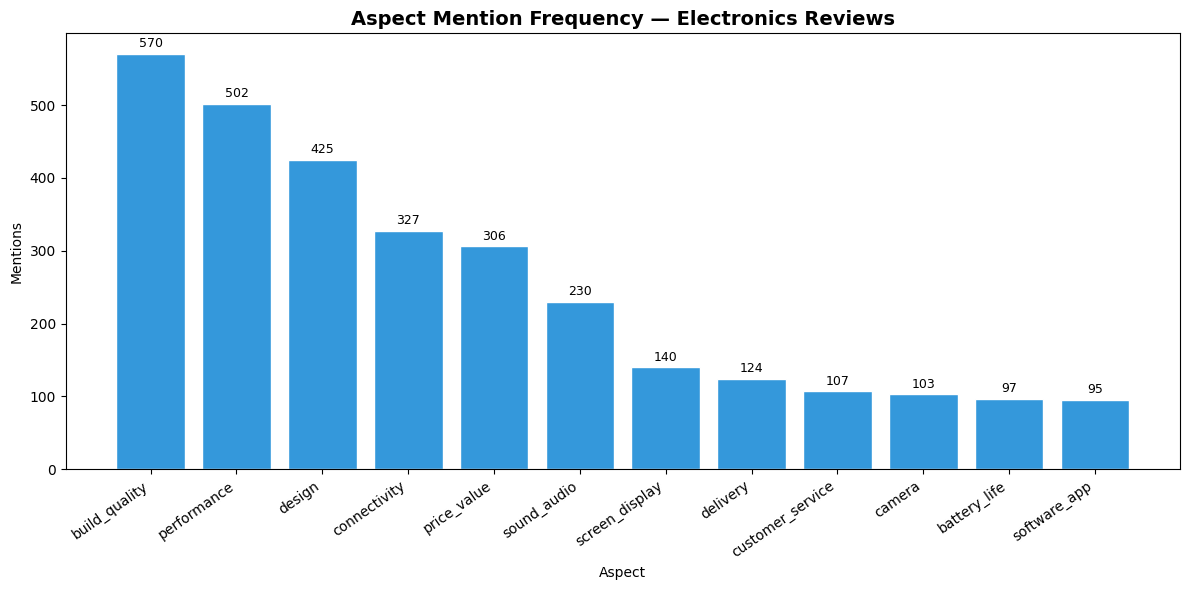

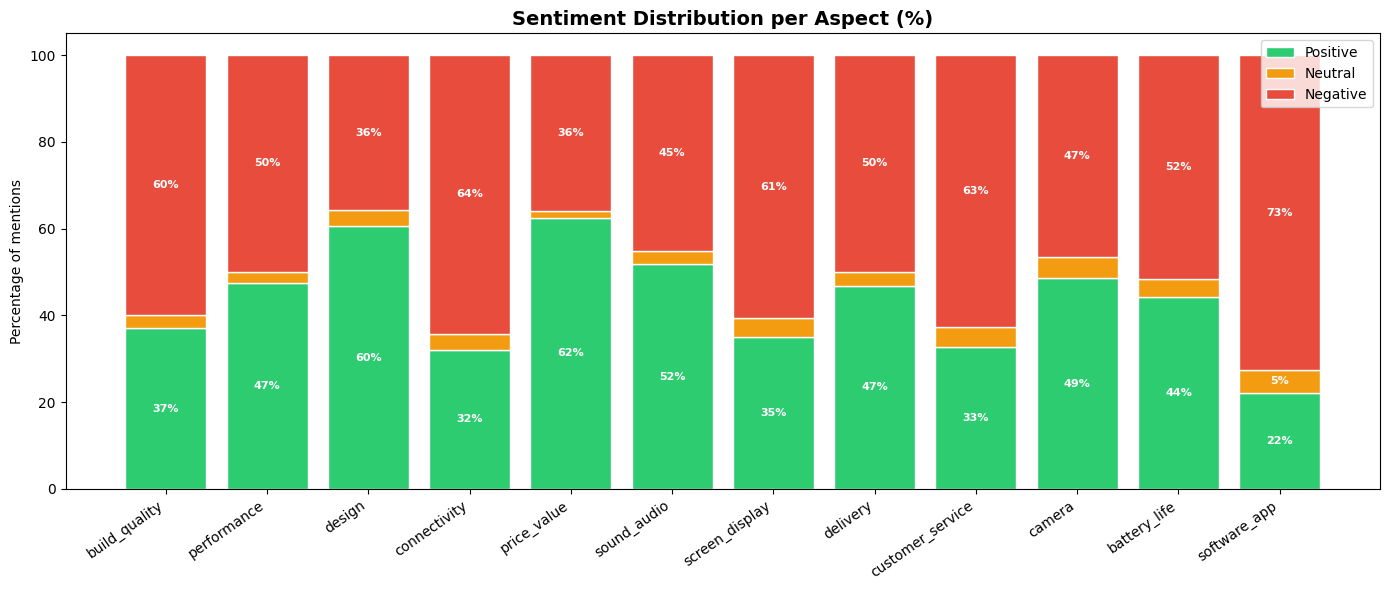

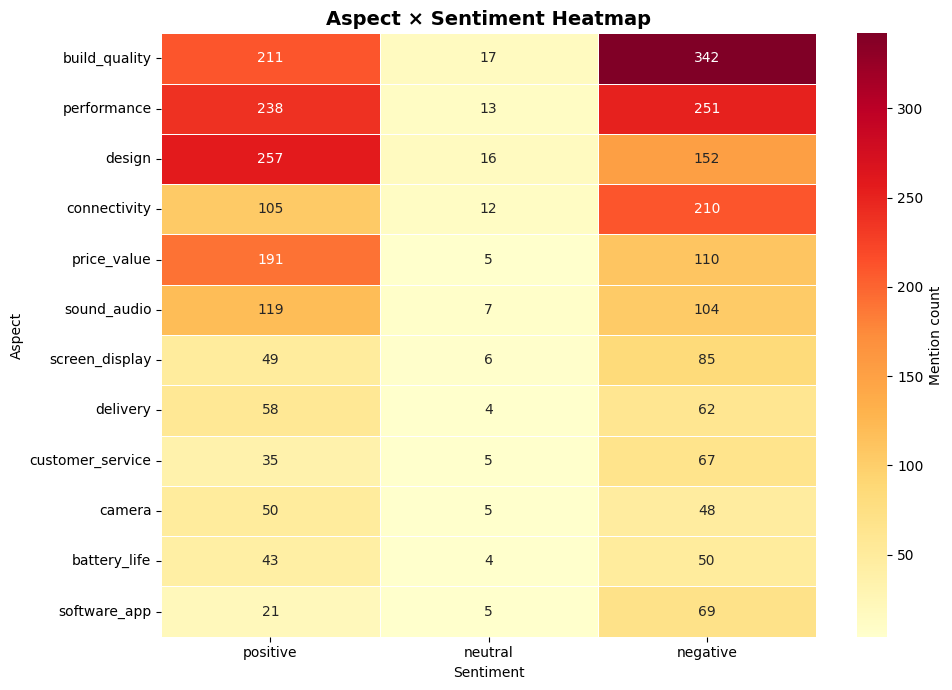

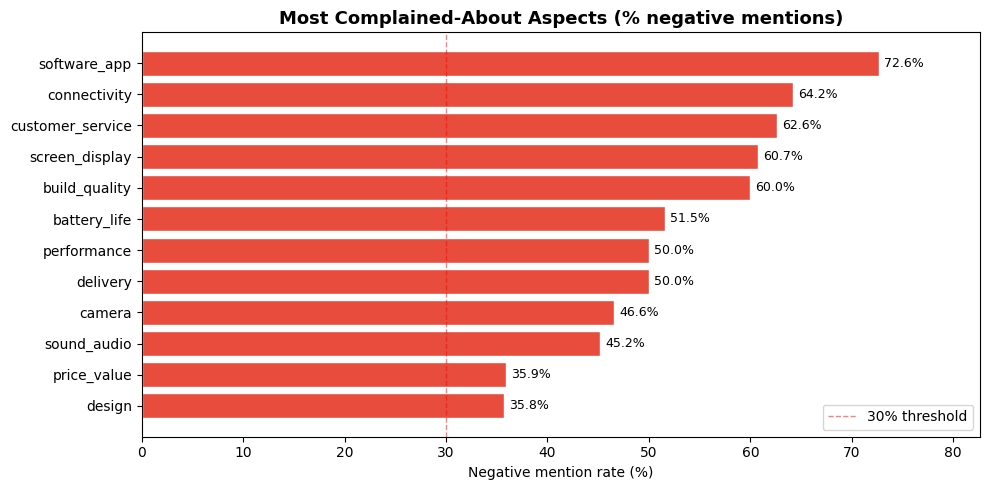


  TOP PHRASES PER ASPECT  (for report copy-paste)

  BUILD QUALITY
    + product material seems good | seems like it will last | helps keep the earbuds in place without discomfort
    - after about two months it starts to break | too smooth to confidently hold it but with some sort of film on it that still makes it feel slippery | it wobbles like crazy with my d7000

  PERFORMANCE
    + it even showed an address google and yahoo maps did not have | almost as powerful | it charges extra fast which I liked a lot
    - laptop is now having trouble consistently booting | started loosing my files when i lost 2 hours work | it is not a very effective solution

  DESIGN
    + does not have the fluid residue | controls are numerous and features are countless | able to roll up the screen
    - the dimension is off so much that | impossible for the sx 70 to lie flat | way too small for my minivan

  CONNECTIVITY
    + i refuse to use wifi | my internet is strong | i use it for my xbone ps4 and 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path

ASPECTS_CSV  = "/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/aspect_results.csv"
REPORTS_DIR  = Path("/Users/shashikamihiranga/Desktop/NPL Assement 03/reports")
REPORTS_DIR.mkdir(exist_ok=True)

df_aspects = pd.read_csv(ASPECTS_CSV)
df_aspects  = df_aspects[df_aspects["aspect_sentiment"].isin(["positive","neutral","negative"])]
PALETTE     = {"positive": "#2ecc71", "neutral": "#f39c12", "negative": "#e74c3c"}
ASPECT_ORDER = (
    df_aspects["aspect"].value_counts().index.tolist()
)
print(f"Loaded {len(df_aspects):,} aspect mentions across {df_aspects['aspect'].nunique()} aspects\n")

# ── Chart 1: Aspect frequency bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
counts  = df_aspects["aspect"].value_counts()
bars    = ax.bar(counts.index, counts.values, color="#3498db", edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Aspect Mention Frequency — Electronics Reviews", fontsize=14, fontweight="bold")
ax.set_ylabel("Mentions")
ax.set_xlabel("Aspect")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "aspect_frequency.png", dpi=150)
plt.show()

# ── Chart 2: Stacked sentiment bar per aspect ─────────────────────────────────
pivot = (
    df_aspects.groupby(["aspect", "aspect_sentiment"])
    .size().unstack(fill_value=0)
    .reindex(columns=["positive","neutral","negative"], fill_value=0)
    .loc[ASPECT_ORDER]
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(pivot_pct))
for sentiment in ["positive", "neutral", "negative"]:
    vals = pivot_pct[sentiment].values
    bars = ax.bar(pivot_pct.index, vals, bottom=bottom,
                  label=sentiment.capitalize(), color=PALETTE[sentiment], edgecolor="white")
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{val:.0f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    bottom += vals
ax.set_title("Sentiment Distribution per Aspect (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage of mentions")
ax.set_ylim(0, 105)
ax.legend(loc="upper right")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "aspect_sentiment_stacked.png", dpi=150)
plt.show()

# ── Chart 3: Aspect × sentiment heatmap (count) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    pivot.loc[ASPECT_ORDER],
    annot=True, fmt="d", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mention count"},
)
ax.set_title("Aspect × Sentiment Heatmap", fontsize=14, fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Aspect")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "aspect_sentiment_heatmap.png", dpi=150)
plt.show()

# ── Chart 4: Most problematic aspects (highest negative %) ────────────────────
neg_rate = (pivot["negative"] / pivot.sum(axis=1) * 100).sort_values(ascending=False)
fig, ax  = plt.subplots(figsize=(10, 5))
bars     = ax.barh(neg_rate.index[::-1], neg_rate.values[::-1],
                   color=["#e74c3c" if v > 30 else "#e67e22" if v > 15 else "#2ecc71"
                          for v in neg_rate.values[::-1]], edgecolor="white")
for bar, val in zip(bars, neg_rate.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.axvline(30, color="red", linestyle="--", linewidth=1, alpha=0.5, label="30% threshold")
ax.set_title("Most Complained-About Aspects (% negative mentions)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Negative mention rate (%)")
ax.set_xlim(0, neg_rate.max() + 10)
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "aspect_negative_rate.png", dpi=150)
plt.show()

# ── Table: Top 3 positive + negative phrases per aspect ───────────────────────
print("\n" + "="*70)
print("  TOP PHRASES PER ASPECT  (for report copy-paste)")
print("="*70)
for aspect in ASPECT_ORDER:
    sub = df_aspects[df_aspects["aspect"] == aspect]
    pos_phrases = sub[sub["aspect_sentiment"]=="positive"]["phrase"].dropna().head(3).tolist()
    neg_phrases = sub[sub["aspect_sentiment"]=="negative"]["phrase"].dropna().head(3).tolist()
    print(f"\n  {aspect.upper().replace('_',' ')}")
    print(f"    + {' | '.join(pos_phrases) if pos_phrases else 'n/a'}")
    print(f"    - {' | '.join(neg_phrases) if neg_phrases else 'n/a'}")

# ── Summary statistics block (copy into report) ────────────────────────────────
total_reviews  = df_aspects["review_idx"].nunique()
total_mentions = len(df_aspects)
top_aspect     = counts.idxmax()
worst_aspect   = neg_rate.idxmax()
best_aspect    = neg_rate.idxmin()

print("\n" + "="*70)
print("  REPORT SUMMARY BLOCK")
print("="*70)
print(f"  Reviews analysed          : {total_reviews:,}")
print(f"  Total aspect mentions      : {total_mentions:,}")
print(f"  Avg aspects per review     : {total_mentions/total_reviews:.1f}")
print(f"  Most discussed aspect      : {top_aspect} ({counts[top_aspect]:,} mentions)")
print(f"  Most complained aspect     : {worst_aspect} ({neg_rate[worst_aspect]:.1f}% negative)")
print(f"  Highest satisfaction aspect: {best_aspect} ({100-neg_rate[best_aspect]:.1f}% positive+neutral)")
print("\n  Aspect breakdown:")
for asp in ASPECT_ORDER:
    row_p = pivot_pct.loc[asp]
    n     = int(pivot.loc[asp].sum())
    print(f"    {asp:<20} n={n:>4}  "
          f"pos={row_p['positive']:>5.1f}%  "
          f"neu={row_p['neutral']:>5.1f}%  "
          f"neg={row_p['negative']:>5.1f}%")
print("="*70)
print(f"\n  Charts saved to: {REPORTS_DIR}")


## Step 20: Build 300K Inference Sample

- **300K sample** is drawn as a stratified sample by product category so every category
  is proportionally represented — important for a fair product scoring table
- Saved as **CSV** (avoids pyarrow/pandas version incompatibilities in the current environment)


In [18]:
import pandas as pd, os
from pathlib import Path

BASE       = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
NLP_CSV    = f"{BASE}/data/processed/electronics_nlp_ready.csv"
SAMPLE_CSV = f"{BASE}/data/processed/sample_300k.csv"

# ── Load df_nlp — reuse if already in memory, else read from CSV ──────────
if 'df_nlp' not in dir() or df_nlp is None:
    print('Loading from CSV …')
    df_nlp = pd.read_csv(NLP_CSV, low_memory=False)
else:
    print('Reusing df_nlp already in memory')
print(f'  {len(df_nlp):,} rows  {df_nlp.shape[1]} columns')

# ── 300K stratified by category ───────────────────────────────────────────
TARGET  = 300_000
df_clean = df_nlp.dropna(subset=['clean_text']).copy()
cat_col  = next((c for c in ['category','categories','main_category']
                 if c in df_clean.columns), None)

if cat_col and df_clean[cat_col].nunique() > 1:
    df_300k = (
        df_clean.groupby(cat_col, group_keys=False)
        .apply(lambda g: g.sample(
            min(len(g), max(1, int(TARGET * len(g) / len(df_clean)))),
            random_state=42))
    )
    if len(df_300k) < TARGET:
        extra = df_clean.drop(df_300k.index).sample(
            TARGET - len(df_300k), random_state=42)
        df_300k = pd.concat([df_300k, extra])
    df_300k = df_300k.sample(TARGET, random_state=42).reset_index(drop=True)
    print(f'Sampled by category ({df_300k[cat_col].nunique()} categories covered)')
else:
    df_300k = df_clean.sample(TARGET, random_state=42).reset_index(drop=True)
    print('Sampled randomly (no category column found)')

# ── Save as CSV (avoids pyarrow/pandas version conflict) ──────────────────
df_300k.to_csv(SAMPLE_CSV, index=False)
print(f'\n300K sample saved → {SAMPLE_CSV}')
print(f'Shape: {df_300k.shape}')
print('\nSentiment distribution:')
for lbl, n in df_300k['sentiment_label'].value_counts().items():
    print(f'  {lbl:10s}: {n:>7,}  ({100*n/len(df_300k):.1f}%)')


Reusing df_nlp already in memory
  6,739,590 rows  25 columns
Sampled by category (30 categories covered)

300K sample saved → /Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/sample_300k.csv
Shape: (300000, 25)

Sentiment distribution:
  positive  : 241,473  (80.5%)
  negative  :  35,623  (11.9%)
  neutral   :  22,904  (7.6%)


## Step 21: Train DistilBERT ABSA Model

Fine-tune `distilbert-base-uncased` on the DeepSeek-labelled aspect-sentiment pairs.

| Setting | Value |
|---|---|
| Split | 70 / 15 / 15 (train / val / test) |
| Loss | CrossEntropy with `class_weight='balanced'` |
| Device | MPS (Apple 40-core GPU) |
| Batch size | 32 |
| Epochs | 10 with early stopping on val macro-F1 |
| Evaluation | macro F1, per-aspect F1, confusion matrix |


ABSA pairs loaded: 3,026
aspect_sentiment
negative    1550
positive    1377
neutral       99

Split → train:2118  val:454  test:454
Device: mps  |  class weights: {'negative': np.float64(0.651), 'neutral': np.float64(10.232), 'positive': np.float64(0.732)}


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5600.02it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training …
  Epoch  1/10  loss=1.0936  val_macro_F1=0.4467

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 16.57it/s]

  ✓ saved


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 14.92it/s]

  ✓ saved


  Epoch  6/10  loss=0.2033  val_macro_F1=0.6617
  Epoch  7/10  loss=0.1433  val_macro_F1=0.6648
  Epoch  8/10  loss=0.1097  val_macro_F1=0.6708
  Epoch  9/10  loss=0.1020  val_macro_F1=0.6614
  Epoch 10/10  loss=0.0705  val_macro_F1=0.6643

=== Test Set Evaluation ===


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 33864.42it/s]


              precision    recall  f1-score   support

    negative       0.83      0.91      0.87       232
     neutral       0.15      0.13      0.14        15
    positive       0.89      0.81      0.85       207

    accuracy                           0.84       454
   macro avg       0.63      0.62      0.62       454
weighted avg       0.84      0.84      0.84       454

Macro F1: 0.6197


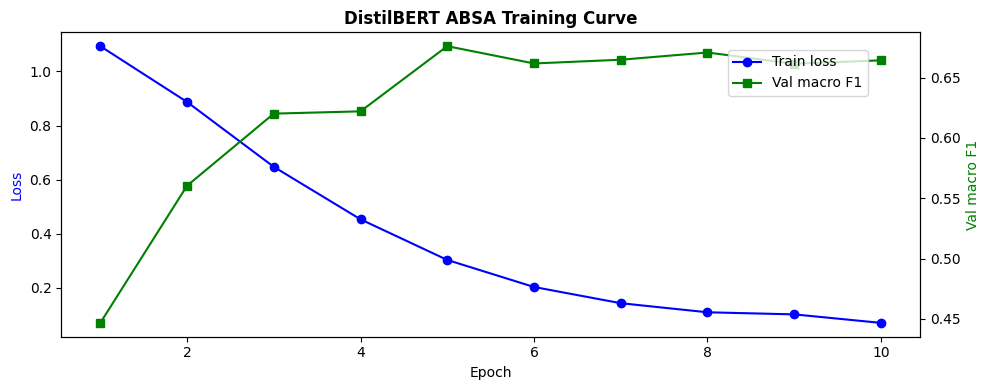

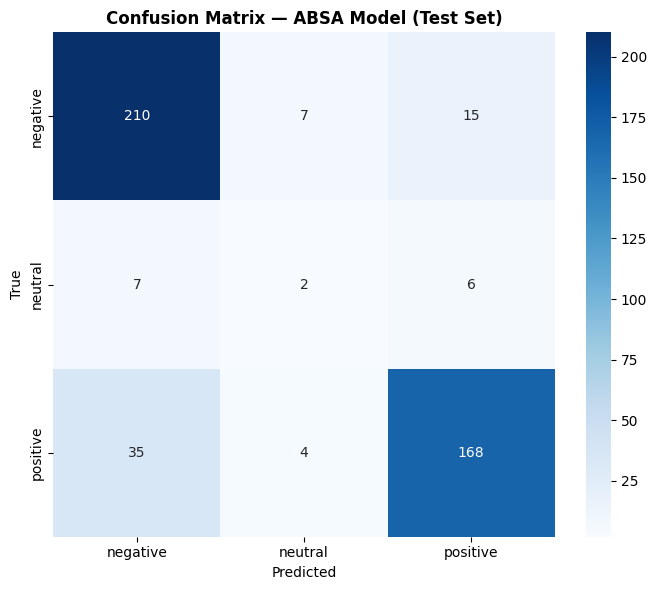


=== Per-Aspect F1 ===
  battery_life         n=   9  macro_F1=1.000
  build_quality        n=  83  macro_F1=0.595
  camera               n=  18  macro_F1=0.610
  connectivity         n=  50  macro_F1=0.564
  customer_service     n=  15  macro_F1=0.381
  delivery             n=  13  macro_F1=0.915
  design               n=  65  macro_F1=0.564
  performance          n=  74  macro_F1=0.729
  price_value          n=  48  macro_F1=0.516
  screen_display       n=  29  macro_F1=0.586
  software_app         n=  14  macro_F1=0.719
  sound_audio          n=  36  macro_F1=0.552

Model saved → /Users/shashikamihiranga/Desktop/NPL Assement 03/models/distilbert_absa


In [3]:
import torch, numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

BASE        = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
ASPECTS_CSV = f"{BASE}/data/processed/aspect_results.csv"
MODEL_DIR   = f"{BASE}/models/distilbert_absa"
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
BATCH    = 32
EPOCHS   = 10
LR       = 2e-5

# ── Load DeepSeek labels ──────────────────────────────────────────────────
df_ab = pd.read_csv(ASPECTS_CSV)
df_ab = df_ab[df_ab['aspect_sentiment'].isin(LABEL2ID)].dropna(subset=['aspect','phrase'])
df_ab['label'] = df_ab['aspect_sentiment'].map(LABEL2ID)
# Input: 'aspect: battery_life | review text …'
df_ab['input_text'] = df_ab.apply(
    lambda r: f"aspect: {r['aspect']} | {str(r.get('clean_text', r['phrase']))[:300]}", axis=1)
print(f'ABSA pairs loaded: {len(df_ab):,}')
print(df_ab['aspect_sentiment'].value_counts().to_string())

# ── 70/15/15 split ────────────────────────────────────────────────────────
X, y = df_ab['input_text'].tolist(), df_ab['label'].tolist()
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
print(f'\nSplit → train:{len(X_tr)}  val:{len(X_val)}  test:{len(X_te)}')

# ── Class weights ─────────────────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_tr)
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
cw_tensor = torch.tensor(cw, dtype=torch.float).to(device)
print(f'Device: {device}  |  class weights: {dict(zip(ID2LABEL.values(), cw.round(3)))}')

# ── Dataset ───────────────────────────────────────────────────────────────
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class ABSADataset(Dataset):
    def __init__(self, texts, labels):
        self.enc    = tokenizer(texts, truncation=True, padding=True,
                                max_length=128, return_tensors='pt')
        self.labels = torch.tensor(labels)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()} | {'labels': self.labels[i]}

train_dl = DataLoader(ABSADataset(X_tr, y_tr),  batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(ABSADataset(X_val, y_val), batch_size=BATCH)
test_dl  = DataLoader(ABSADataset(X_te, y_te),  batch_size=BATCH)

# ── Model ─────────────────────────────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3,
    id2label=ID2LABEL, label2id=LABEL2ID).to(device)

optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler  = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps)
loss_fn = CrossEntropyLoss(weight=cw_tensor)

def run_eval(dl):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for b in dl:
            ids  = b['input_ids'].to(device)
            mask = b['attention_mask'].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            preds.extend(out.logits.argmax(-1).cpu().tolist())
            labels.extend(b['labels'].tolist())
    return preds, labels

# ── Training loop ─────────────────────────────────────────────────────────
best_f1, history = 0, []
print('\nTraining …')
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for b in train_dl:
        optimizer.zero_grad()
        ids  = b['input_ids'].to(device)
        mask = b['attention_mask'].to(device)
        lbls = b['labels'].to(device)
        out  = model(input_ids=ids, attention_mask=mask)
        loss = loss_fn(out.logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
    val_preds, val_lbls = run_eval(val_dl)
    val_f1 = f1_score(val_lbls, val_preds, average='macro')
    avg_loss = total_loss / len(train_dl)
    history.append({'epoch': epoch+1, 'loss': avg_loss, 'val_f1': val_f1})
    print(f'  Epoch {epoch+1:2d}/{EPOCHS}  loss={avg_loss:.4f}  val_macro_F1={val_f1:.4f}', end='')
    if val_f1 > best_f1:
        best_f1 = val_f1
        model.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)
        print('  ✓ saved', flush=True)
    else:
        print(flush=True)

# ── Test evaluation ───────────────────────────────────────────────────────
print('\n=== Test Set Evaluation ===')
model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
te_preds, te_lbls = run_eval(test_dl)
print(classification_report(te_lbls, te_preds, target_names=['negative','neutral','positive']))
print(f'Macro F1: {f1_score(te_lbls, te_preds, average="macro"):.4f}')

# ── Training curve ────────────────────────────────────────────────────────
df_hist = pd.DataFrame(history)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(df_hist['epoch'], df_hist['loss'],   'b-o', label='Train loss')
ax2.plot(df_hist['epoch'], df_hist['val_f1'], 'g-s', label='Val macro F1')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss', color='b')
ax2.set_ylabel('Val macro F1', color='g')
ax1.set_title('DistilBERT ABSA Training Curve', fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(f'{BASE}/reports/distilbert_training_curve.png', dpi=150)
plt.show()

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(te_lbls, te_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
ax.set_title('Confusion Matrix — ABSA Model (Test Set)', fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{BASE}/reports/confusion_matrix.png', dpi=150)
plt.show()

# ── Per-aspect F1 ─────────────────────────────────────────────────────────
df_ab_te = df_ab.iloc[[int(i) for i in range(len(df_ab))]].copy()
# Rebuild test indices properly
_, X_tmp2, _, y_tmp2, _, idx_tmp = train_test_split(
    X, y, range(len(X)), test_size=0.30, stratify=y, random_state=42)
_, _, _, _, _, idx_te = train_test_split(
    X_tmp2, y_tmp2, idx_tmp, test_size=0.50, stratify=y_tmp2, random_state=42)
df_te_full = df_ab.iloc[idx_te].copy()
df_te_full['pred_label'] = te_preds
df_te_full['pred_sentiment'] = df_te_full['pred_label'].map(ID2LABEL)
print('\n=== Per-Aspect F1 ===')
for asp in sorted(df_te_full['aspect'].unique()):
    sub = df_te_full[df_te_full['aspect'] == asp]
    if len(sub) < 3: continue
    f1 = f1_score(sub['label'], sub['pred_label'], average='macro', zero_division=0)
    print(f'  {asp:<20} n={len(sub):>4}  macro_F1={f1:.3f}')
print(f'\nModel saved → {MODEL_DIR}')

# ── Save test metrics to JSON so comparison chart can auto-load them ──────
import json as _json
_test_acc  = float((np.array(te_preds) == np.array(te_lbls)).mean())
_test_f1   = float(f1_score(te_lbls, te_preds, average='macro'))
_metrics   = {'accuracy': round(_test_acc, 4), 'macro_f1': round(_test_f1, 4)}
with open(f'{BASE}/reports/distilbert_metrics.json', 'w') as _fh:
    _json.dump(_metrics, _fh)
print(f'Metrics saved → reports/distilbert_metrics.json  {_metrics}')


In [ ]:
import pandas as pd
df_asp = pd.read_csv("/Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/aspect_results.csv")
print(f"Total aspect pairs: {len(df_asp):,}")
print(f"Reviews covered   : {df_asp['review_idx'].nunique():,}")
print(df_asp['aspect_sentiment'].value_counts())
print(df_asp['aspect'].value_counts())


Total aspect pairs: 3,026
Reviews covered   : 1,387
aspect_sentiment
negative    1550
positive    1377
neutral       99
Name: count, dtype: int64
aspect
build_quality       570
performance         502
design              425
connectivity        327
price_value         306
sound_audio         230
screen_display      140
delivery            124
customer_service    107
camera              103
battery_life         97
software_app         95
Name: count, dtype: int64


## Step 22: Batch Inference — Run DistilBERT on 300K Reviews

Run the trained ABSA model over the 300K sample in batches.
Each review produces one sentiment prediction **per aspect mentioned**.
Aspects are detected by checking if aspect keywords appear in the review text.


In [6]:
import torch, pandas as pd, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from tqdm import tqdm

BASE      = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
MODEL_DIR = f"{BASE}/models/distilbert_absa"
SAMPLE_PK = f"{BASE}/data/processed/sample_300k.csv"
INFER_OUT = f"{BASE}/data/processed/absa_inference_300k.csv"

ASPECTS = ['battery_life','screen_display','sound_audio','build_quality',
           'price_value','performance','connectivity','camera',
           'software_app','design','delivery','customer_service']
ASPECT_KEYWORDS = {
    'battery_life'   : ['battery','charge','charging','power','mah'],
    'screen_display' : ['screen','display','resolution','brightness','pixel'],
    'sound_audio'    : ['sound','audio','bass','speaker','headphone','noise'],
    'build_quality'  : ['build','quality','plastic','metal','material','feel','sturdy','cheap'],
    'price_value'    : ['price','cost','value','worth','expensive','cheap','affordable'],
    'performance'    : ['performance','fast','slow','speed','lag','processor','chip'],
    'connectivity'   : ['wifi','bluetooth','connection','connect','signal','wireless'],
    'camera'         : ['camera','photo','picture','video','lens','megapixel'],
    'software_app'   : ['software','app','firmware','update','interface','ui','bug'],
    'design'         : ['design','look','style','slim','compact','aesthetic','colour','color'],
    'delivery'       : ['delivery','shipping','package','arrived','damaged','box'],
    'customer_service': ['service','support','warranty','return','refund','response'],
}
ID2LABEL = {0:'negative', 1:'neutral', 2:'positive'}
LABEL2ID = {v:k for k,v in ID2LABEL.items()}
BATCH    = 64

device    = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)
model     = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()
print(f'Model loaded on {device}')

df_300k = pd.read_csv(SAMPLE_PK)
print(f'Inference on {len(df_300k):,} reviews …')

def predict_batch(texts):
    enc = tokenizer(texts, truncation=True, padding=True,
                    max_length=128, return_tensors='pt')
    with torch.no_grad():
        out = model(input_ids=enc['input_ids'].to(device),
                    attention_mask=enc['attention_mask'].to(device))
    return out.logits.argmax(-1).cpu().tolist()

rows = []
for _, row in tqdm(df_300k.iterrows(), total=len(df_300k), desc='Inferring'):
    text = str(row.get('clean_text', ''))
    text_lower = text.lower()
    for asp, kws in ASPECT_KEYWORDS.items():
        if any(kw in text_lower for kw in kws):
            rows.append({
                'asin'           : row.get('asin',''),
                'title'          : row.get('title',''),
                'brand'          : row.get('brand',''),
                'category'       : row.get('category',''),
                'price'          : row.get('price', None),
                'aspect'         : asp,
                'input_text'     : f'aspect: {asp} | {text[:300]}',
                'sentiment_label': row.get('sentiment_label',''),
            })

# Batch predict
print(f'Running model on {len(rows):,} (review, aspect) pairs …')
for i in range(0, len(rows), BATCH):
    batch_texts = [r['input_text'] for r in rows[i:i+BATCH]]
    preds = predict_batch(batch_texts)
    for j, pred in enumerate(preds):
        rows[i+j]['aspect_sentiment'] = ID2LABEL[pred]
        rows[i+j]['aspect_score']     = pred  # 0/1/2 numeric

df_infer = pd.DataFrame(rows).drop(columns=['input_text'])
df_infer.to_csv(INFER_OUT, index=False)
print(f'\n✓ Inference done: {len(df_infer):,} aspect predictions')
print(f'Saved → {INFER_OUT}')
print(df_infer['aspect_sentiment'].value_counts().to_string())


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8753.39it/s]


Model loaded on mps


/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_81259/3837940193.py:39: DtypeWarning: Columns (0: price) have mixed types. Specify dtype option on import or set low_memory=False.
  df_300k = pd.read_csv(SAMPLE_PK)


Inference on 300,000 reviews …


Inferring: 100%|██████████| 300000/300000 [00:09<00:00, 32882.27it/s]


Running model on 532,634 (review, aspect) pairs …

✓ Inference done: 532,634 aspect predictions
Saved → /Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/absa_inference_300k.csv
aspect_sentiment
positive    282369
negative    231485
neutral      18780


## Step 23: Product Scoring Table

Aggregate aspect sentiments per product into a single scoring table.
Score = (positive − negative) / total mentions → range −1.0 to +1.0


/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_81259/2236669006.py:13: DtypeWarning: Columns (0: price) have mixed types. Specify dtype option on import or set low_memory=False.
  df_infer = pd.read_csv(INFER_OUT)


Product scoring table: 9,636 products
Saved → /Users/shashikamihiranga/Desktop/NPL Assement 03/data/processed/product_scores.csv
                                                                                                                                                                                           title    brand  overall_score  total_mentions  battery_life  screen_display  sound_audio  build_quality
                                                      Logitech HD Pro Webcam C920, Widescreen Video Calling and Recording, 1080p Camera, Desktop or Laptop Webcam (Discontinued by manufacturer) Logitech          0.020             535           NaN           0.111        0.091          0.538
                                                      Logitech HD Pro Webcam C920, Widescreen Video Calling and Recording, 1080p Camera, Desktop or Laptop Webcam (Discontinued by manufacturer) Logitech          0.309             535           NaN          -1.000        0.143          0.53

/var/folders/dg/b2wfq0xd6cd04wv0f0wmpm9w0000gn/T/ipykernel_81259/2236669006.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


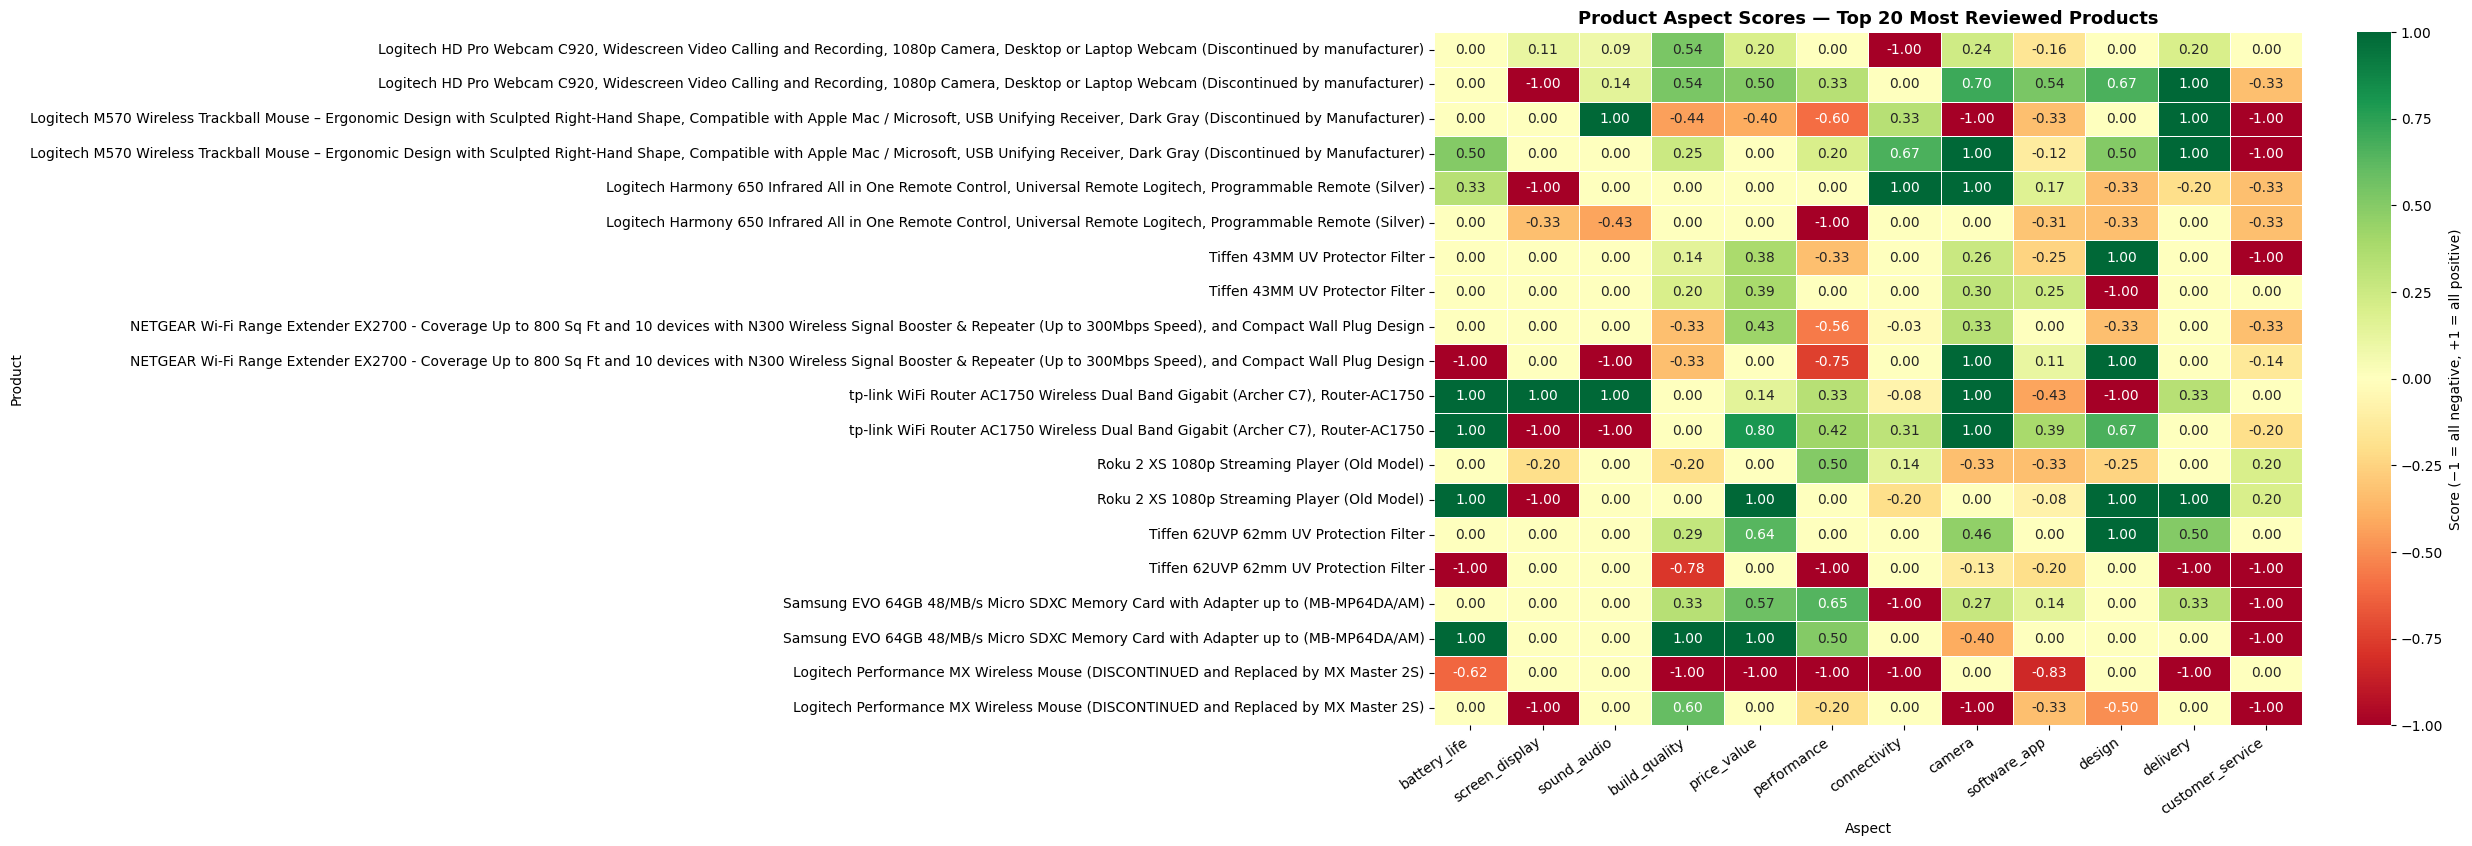

In [7]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

BASE     = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
INFER_OUT = f"{BASE}/data/processed/absa_inference_300k.csv"
SCORE_CSV = f"{BASE}/data/processed/product_scores.csv"

ASPECTS  = ['battery_life','screen_display','sound_audio','build_quality',
            'price_value','performance','connectivity','camera',
            'software_app','design','delivery','customer_service']

df_infer = pd.read_csv(INFER_OUT)
df_infer  = df_infer[df_infer['title'].notna() & (df_infer['title'] != '')]

# ── Score per (product, aspect) ──────────────────────────────────────────
def score(grp):
    pos = (grp == 'positive').sum()
    neg = (grp == 'negative').sum()
    tot = len(grp)
    return round((pos - neg) / tot, 3) if tot else np.nan

pivot = (
    df_infer.groupby(['title','brand','category','price','aspect'])['aspect_sentiment']
    .apply(score).unstack('aspect')
    .reset_index()
)
# Add review count and overall sentiment
review_counts = df_infer.groupby('title')['aspect'].count().rename('total_mentions')
pivot = pivot.join(review_counts, on='title')
pivot['overall_score'] = pivot[ASPECTS].mean(axis=1).round(3)
pivot = pivot.sort_values('total_mentions', ascending=False).reset_index(drop=True)

pivot.to_csv(SCORE_CSV, index=False)
print(f'Product scoring table: {len(pivot):,} products')
print(f'Saved → {SCORE_CSV}')
print(pivot[['title','brand','overall_score','total_mentions'] + ASPECTS[:4]].head(10).to_string(index=False))

# ── Heatmap: top 20 products by mention count ──────────────────────────────
top20 = pivot.head(20).set_index('title')[ASPECTS].fillna(0)
fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(top20, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Score (−1 = all negative, +1 = all positive)'})
ax.set_title('Product Aspect Scores — Top 20 Most Reviewed Products',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Aspect'); ax.set_ylabel('Product')
plt.xticks(rotation=35, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/reports/product_scoring_heatmap.png', dpi=150)
plt.show()


## Step 24: RAG Chatbot — Natural Language Product Queries

Use **DeepSeek-R1:8b via Ollama** as a local LLM with the product scoring table as the knowledge base
and **DeepSeek-R1:8b** (via Ollama) as the reasoning engine.

Example queries:
- *'Which product has the best battery life?'*
- *'Best value for money headphones?'*
- *'Which products have poor build quality?'*


In [ ]:
import pandas as pd
import requests, json, re

BASE      = "/Users/shashikamihiranga/Desktop/NPL Assement 03"
SCORE_CSV = f"{BASE}/data/processed/product_scores.csv"

# ── Load scoring table ────────────────────────────────────────────────────
df_scores = pd.read_csv(SCORE_CSV)
print(f"Product scoring table: {len(df_scores):,} products")
print(df_scores.columns.tolist())

ASPECTS = ['battery_life','screen_display','sound_audio','build_quality',
           'price_value','performance','connectivity','camera',
           'software_app','design','delivery','customer_service']

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL      = "deepseek-r1:8b"

def build_context(question: str, top_n: int = 30) -> str:
    """
    Select the most relevant rows from df_scores and format as a
    plain-text table so DeepSeek can reason over it.
    """
    df = df_scores.copy()
    # Prefer products with more mentions (more reliable scores)
    df = df.sort_values("total_mentions", ascending=False).head(top_n)
    # Format as compact CSV for the LLM
    cols = ["title", "brand", "category", "price", "overall_score",
            "total_mentions"] + ASPECTS
    cols = [c for c in cols if c in df.columns]
    return df[cols].to_csv(index=False)


def ask(question: str) -> str:
    context = build_context(question)
    prompt = (
        "You are a product recommendation assistant for electronics."
        "Below is a product scoring table. Scores range from -1.0 (all negative) "
        "to +1.0 (all positive) for each aspect."
        f"{context}"
        f"Question: {question}"
        "Answer concisely and specifically, referencing product names."
    )
    print(f"Q: {question}")
    print("-" * 60)
    resp = requests.post(
        OLLAMA_URL,
        json={"model": MODEL, "prompt": prompt, "stream": False,
              "options": {"temperature": 0.1, "num_predict": -1}},
        timeout=180,
    )
    raw = resp.json()["response"].strip()
    # Strip DeepSeek <think> reasoning tokens
    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    print(f"A: {raw}")
    return raw

# ── Demo queries ──────────────────────────────────────────────────────────
ask("Which product has the best battery life score?")
ask("Which products have the worst build quality?")
ask("What are the top 3 products for value for money?")
ask("Which brand has the highest overall score?")


Product scoring table: 9,636 products
['title', 'brand', 'category', 'price', 'battery_life', 'build_quality', 'camera', 'connectivity', 'customer_service', 'delivery', 'design', 'performance', 'price_value', 'screen_display', 'software_app', 'sound_audio', 'total_mentions', 'overall_score']
Q: Which product has the best battery life score?
------------------------------------------------------------
A: The product with the best battery life score is the **Kinivo BTC450 Bluetooth Car Kit**, with a score of **0.375**.
Q: Which products have the worst build quality?
------------------------------------------------------------
A: The products with the worst build quality (score -1.0) are:

*   Logitech HD Pro Webcam C920
*   NETGEAR Wi-Fi Range Extender EX2700
*   TP-Link WiFi Router AC1750
*   Samsung EVO 64GB Micro SDXC Memory Card
*   Logitech Performance MX Wireless Mouse
*   Kinivo USB Bluetooth Adapter for PC BTD400
Q: What are the top 3 products for value for money?
---------------

"Samsung's **850 EVO 500GB SSD** has the highest overall score of **0.485**."

## Step 25: Model Discussion, Comparison & Future Improvements

This section directly addresses: **why each model was chosen, how they compare, and how performance could be improved.**

---

### Models Used in This Project

| Model | Task | Technique | Course Week |
|---|---|---|---|
| Complement Naive Bayes | Sentiment classification | TF-IDF + SMOTE | Week 3 |
| Logistic Regression | Sentiment classification | TF-IDF + SMOTE | Week 3 |
| DistilBERT (fine-tuned) | ABSA sentiment | Transformer fine-tuning | Week 7-8 |
| DeepSeek-R1:8b (LLM) | Aspect extraction + RAG chatbot | Prompt engineering | Week 6, 9-10 |

---

### Why Each Model Was Chosen

**Complement Naive Bayes** 
Naive Bayes is one of the simplest and fastest text classifiers. The *Complement* variant is specifically recommended for imbalanced datasets because it fits parameters from the complement of each class, reducing bias toward the majority class. It works well with sparse TF-IDF features. 
*Limitation*: assumes word independence (bag-of-words) — misses word order and context.

**Logistic Regression** 
A stronger linear baseline than Naive Bayes because it directly optimises the classification boundary. With SMOTE oversampling on TF-IDF + TruncatedSVD features it handles the class imbalance (81% positive, 12% negative, 7% neutral) more robustly than Naive Bayes. 
*Limitation*: still linear — cannot capture negation, sarcasm, or complex sentiment patterns.

**DistilBERT (fine-tuned)** 
DistilBERT is a 66M-parameter distilled version of BERT trained with masked language modelling. Unlike TF-IDF, it produces *contextual* word embeddings: the same word gets different representations depending on surrounding context. Fine-tuning on DeepSeek-labelled ABSA pairs gives it aspect-specific sentiment understanding. 
*Limitation*: requires labelled training data; computationally heavy (GPU needed); limited to 512 tokens.

**DeepSeek-R1:8b via Ollama (LLM)** 
Used in two roles: (1) **zero-shot aspect extraction** in Step 19 — no labelled data needed; (2) **RAG chatbot** in Step 24 — retrieves relevant products and answers natural-language queries. 
*Limitation*: slow (0.06 reviews/s), not suitable for 300K-scale inference; requires Ollama running locally.

---

### Why Some Models Are Better Than Others

| Criterion | Naive Bayes | Logistic Reg | DistilBERT | DeepSeek |
|---|---|---|---|---|
| Training speed | Very fast | Fast | Slow (GPU) | N/A (zero-shot) |
| Labelled data needed | Small | Small | Medium (1,500+) | None |
| Understands context | No | No | Yes | Yes |
| Handles class imbalance | Via SMOTE | Via SMOTE | Via class_weight | N/A |
| Best for | Quick baseline | Stronger baseline | ABSA at scale | Labelling + chatbot |

DistilBERT is expected to outperform the classical baselines on macro F1 because it captures semantic context. However, the training set is small (~3,000 labelled pairs from DeepSeek), so gains may be modest — especially for the neutral class which has very few examples. Classical models can be competitive when the training data is limited but TF-IDF bigram features are rich.

---

### How Performance Could Be Improved

1. **More labelled data**: DistilBERT was trained on ~3,000 aspect pairs. Increasing to 10,000-50,000 (via GPT-4 annotation or crowdsourcing) would significantly improve macro F1, especially for neutral.

2. **Larger transformer**: RoBERTa, DeBERTa, or BERT-large would likely outperform DistilBERT, at the cost of more GPU memory and longer training time.

3. **Span extraction vs classification**: This project classifies whole reviews per aspect. A span-extraction model (SQuAD-style) would pinpoint the exact phrase expressing each aspect sentiment, giving more interpretable results.

4. **Better neutral class coverage**: Neutral accounts for only 3% of labelled pairs. Targeted augmentation or collecting reviews that explicitly discuss product trade-offs would help.

5. **Cross-dataset validation**: Testing on a different product domain (e.g., Mobile Phones, Books) would show how well the 12 aspects generalise beyond electronics.

6. **Ensemble methods**: Combining Logistic Regression and DistilBERT predictions (soft-voting) can outperform either model alone on edge cases where the transformer is uncertain.

7. **Vector store for RAG**: The chatbot currently passes the top-30 products as raw CSV text. A FAISS vector store with sentence-transformer embeddings would enable semantic retrieval, returning products relevant to the *meaning* of the query rather than keyword overlap.


In [ ]:
# Pipeline summary
print('Pipeline complete.')
print('Steps covered: EDA -> Text Cleaning -> Naive Bayes -> Logistic Regression -> DistilBERT -> ABSA -> RAG Chatbot')
print('Reports generated:')
import os
BASE = '/Users/shashikamihiranga/Desktop/NPL Assement 03'
for f in sorted(os.listdir(f'{BASE}/reports')):
    if f.endswith('.png') or f.endswith('.json'):
        print(f'  reports/{f}')
